<a href="https://colab.research.google.com/github/OmarGamalH/Codon-Based-Kingdom-Classification-Using-Machine-Learning/blob/main/Notebooks/Preprocessing_And_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Important Dependencies

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the data

In [132]:
df = pd.read_csv("/content/codon_usage.csv")
df.head()

/tmp/ipykernel_6968/2677559256.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/codon_usage.csv")


,Kingdom,DNAtype,SpeciesID,Ncodons,SpeciesName,UUU,UUC,UUA,UUG,CUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,vrl,0,100217,1995,Epizootic haematopoietic necrosis virus,0.01654,0.01203,0.00050,0.00351,0.01203,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,vrl,0,100220,1474,Bohle iridovirus,0.02714,0.01357,0.00068,0.00678,0.00407,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,vrl,0,100755,4862,Sweet potato leaf curl virus,0.01974,0.0218,0.01357,0.01543,0.00782,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,vrl,0,100880,1915,Northern cereal mosaic virus,0.01775,0.02245,0.01619,0.00992,0.01567,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,vrl,0,100887,22831,Soil-borne cereal mosaic virus,0.02816,0.01371,0.00767,0.03679,0.01380,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131


In [133]:
df.tail()

,Kingdom,DNAtype,SpeciesID,Ncodons,SpeciesName,UUU,UUC,UUA,UUG,CUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
13023,pri,0,9601,1097,Pongo pygmaeus abelii,0.02552,0.03555,0.00547,0.01367,0.01276,...,0.00820,0.01367,0.01094,0.01367,0.02279,0.02005,0.04102,0.00091,0.00091,0.00638
13024,pri,1,9601,2067,mitochondrion Pongo pygmaeus abelii,0.01258,0.03193,0.01984,0.00629,0.01451,...,0.00145,0.00000,0.00048,0.00194,0.01306,0.01838,0.00677,0.00242,0.00097,0.01887
13025,pri,1,9602,1686,mitochondrion Pongo pygmaeus pygmaeus,0.01423,0.03321,0.01661,0.00356,0.01127,...,0.00000,0.00000,0.00000,0.00178,0.01661,0.02788,0.00297,0.00356,0.00119,0.02017
13026,pri,0,9606,40662582,Homo sapiens,0.01757,0.02028,0.00767,0.01293,0.01319,...,0.01142,0.01217,0.01196,0.02178,0.02510,0.02896,0.03959,0.00099,0.00079,0.00156
13027,pri,1,9606,8998998,mitochondrion Homo sapiens,0.01778,0.03724,0.01732,0.00600,0.01689,...,0.00083,0.00041,0.00041,0.00451,0.01402,0.01651,0.00783,0.00156,0.00114,0.02161


# Sanity Check

In [134]:
df.shape

(13028, 69)

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13028 entries, 0 to 13027
Data columns (total 69 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Kingdom      13028 non-null  object 
 1   DNAtype      13028 non-null  int64  
 2   SpeciesID    13028 non-null  int64  
 3   Ncodons      13028 non-null  int64  
 4   SpeciesName  13028 non-null  object 
 5   UUU          13028 non-null  object 
 6   UUC          13028 non-null  object 
 7   UUA          13028 non-null  float64
 8   UUG          13028 non-null  float64
 9   CUU          13028 non-null  float64
 10  CUC          13028 non-null  float64
 11  CUA          13028 non-null  float64
 12  CUG          13028 non-null  float64
 13  AUU          13028 non-null  float64
 14  AUC          13028 non-null  float64
 15  AUA          13028 non-null  float64
 16  AUG          13028 non-null  float64
 17  GUU          13028 non-null  float64
 18  GUC          13028 non-null  float64
 19  GUA 

In [136]:
#Checking for missing values
df.isnull().sum()

,0
Kingdom,0
DNAtype,0
SpeciesID,0
Ncodons,0
SpeciesName,0
...,...
GAA,0
GAG,0
UAA,0
UAG,0


In [137]:
#Finding duplicates
df.duplicated().sum()

np.int64(0)

In [138]:
#Identifying Garbage values
for i in df.select_dtypes(include = "object").columns:
  print(df[i].value_counts())
  print("*"*10)

Kingdom
bct    2920
vrl    2832
pln    2523
vrt    2077
inv    1345
mam     572
phg     220
rod     215
pri     180
arc     126
plm      18
Name: count, dtype: int64
**********
SpeciesName
Escherichia coli O157                         4
Cotton leaf curl Rajasthan virus - [India     3
Ageratum yellow vein Hualian virus-[Taiwan    3
Escherichia coli O111                         3
Honeysuckle yellow vein virus-[Japan          2
                                             ..
Pseudomonas sp. PCL1171                       1
Geobacillus kaustophilus HTA426               1
Brucella ovis                                 1
Microcystis sp. FACHB-854                     1
Arthrospira platensis FACHB341                1
Name: count, Length: 13016, dtype: int64
**********
UUU
0          69
0.04536    34
0.04618    28
0.01423    14
0.00576    13
           ..
0.0297      1
0.02606     1
0.0299      1
0.01876     1
0.02028     1
Name: count, Length: 6797, dtype: int64
**********
UUC
0.02564    42
0.01

# Filtering Some Features

In [139]:
df = df.drop(columns = ["SpeciesName","SpeciesID","DNAtype"])
df.head()

,Kingdom,Ncodons,UUU,UUC,UUA,UUG,CUU,CUC,CUA,CUG,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,vrl,1995,0.01654,0.01203,0.00050,0.00351,0.01203,0.03208,0.00100,0.04010,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,vrl,1474,0.02714,0.01357,0.00068,0.00678,0.00407,0.02849,0.00204,0.04410,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,vrl,4862,0.01974,0.0218,0.01357,0.01543,0.00782,0.01111,0.01028,0.01193,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,vrl,1915,0.01775,0.02245,0.01619,0.00992,0.01567,0.01358,0.00940,0.01723,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,vrl,22831,0.02816,0.01371,0.00767,0.03679,0.01380,0.00548,0.00473,0.02076,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131


In [140]:
df = df[df["Ncodons"] >= 1000]
df.shape

(13028, 66)

In [141]:
df = df.drop(columns = "Ncodons")
df.head()

,Kingdom,UUU,UUC,UUA,UUG,CUU,CUC,CUA,CUG,AUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,vrl,0.01654,0.01203,0.00050,0.00351,0.01203,0.03208,0.00100,0.04010,0.00551,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,vrl,0.02714,0.01357,0.00068,0.00678,0.00407,0.02849,0.00204,0.04410,0.01153,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,vrl,0.01974,0.0218,0.01357,0.01543,0.00782,0.01111,0.01028,0.01193,0.02283,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,vrl,0.01775,0.02245,0.01619,0.00992,0.01567,0.01358,0.00940,0.01723,0.02402,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,vrl,0.02816,0.01371,0.00767,0.03679,0.01380,0.00548,0.00473,0.02076,0.02716,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131


# Exploratory Data Analysis

In [142]:
df.describe()

,UUA,UUG,CUU,CUC,CUA,CUG,AUU,AUC,AUA,AUG,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
count,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,...,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000,13028.000000
mean,0.020637,0.014104,0.017820,0.018288,0.019044,0.018450,0.028352,0.025041,0.018294,0.021135,...,0.005454,0.009929,0.006422,0.024178,0.021164,0.028290,0.021683,0.001645,0.000592,0.006178
std,0.020709,0.009280,0.010586,0.014572,0.024250,0.016578,0.017507,0.014600,0.016044,0.008163,...,0.006605,0.008574,0.006387,0.013828,0.013041,0.014342,0.015018,0.001834,0.000907,0.010344
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.005610,0.007108,0.010890,0.007830,0.005307,0.007180,0.016360,0.015130,0.006320,0.015787,...,0.001220,0.001690,0.001170,0.012380,0.011860,0.017360,0.009710,0.000560,0.000000,0.000410
50%,0.015260,0.013360,0.016130,0.014560,0.009685,0.012800,0.025475,0.021540,0.014140,0.022000,...,0.003530,0.009270,0.004545,0.025420,0.019070,0.026085,0.020540,0.001380,0.000420,0.001130
75%,0.029485,0.019810,0.022730,0.025112,0.017245,0.024315,0.038113,0.031860,0.025970,0.026260,...,0.007150,0.015922,0.010250,0.034190,0.027690,0.036800,0.031122,0.002370,0.000830,0.002890
max,0.151330,0.101190,0.089780,0.100350,0.163920,0.107370,0.154060,0.088600,0.134400,0.101690,...,0.055540,0.098830,0.058430,0.185660,0.113840,0.144890,0.158550,0.045200,0.025610,0.106700


In [143]:
df.describe(include = "object")

,Kingdom,UUU,UUC
count,13028,13028,13028
unique,11,6797,5874
top,bct,0,0.02564
freq,2920,69,42


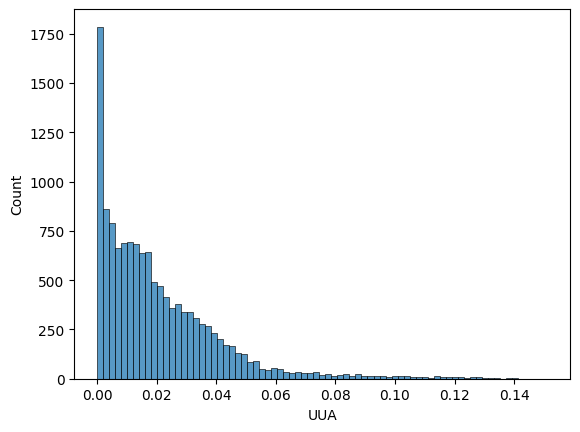

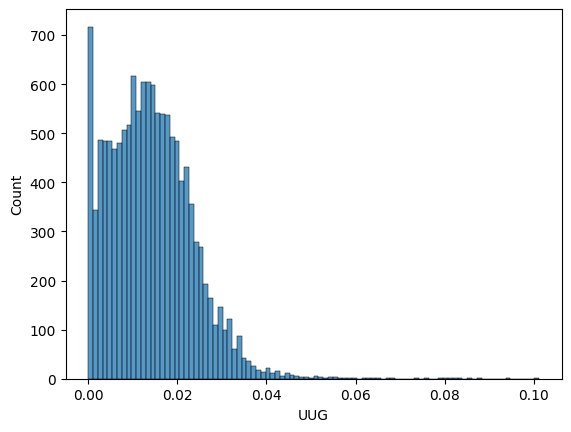

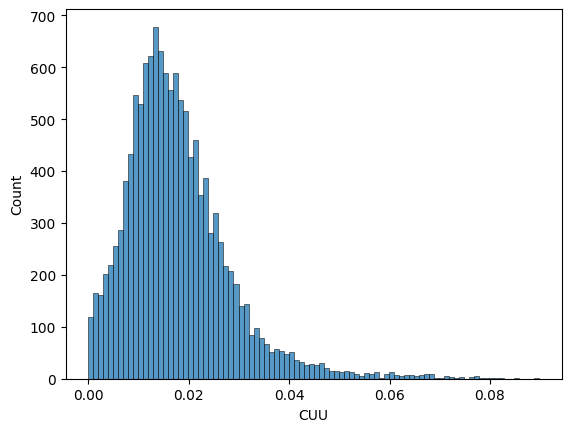

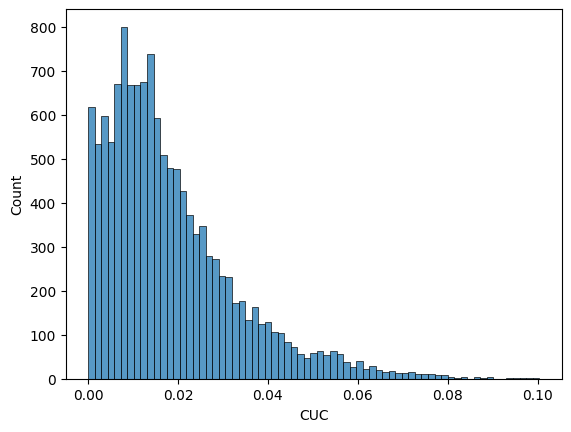

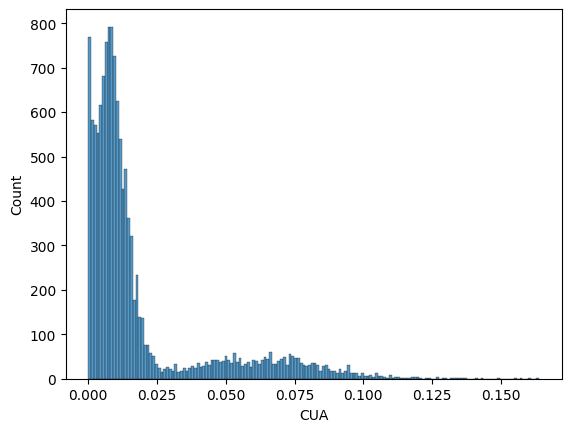

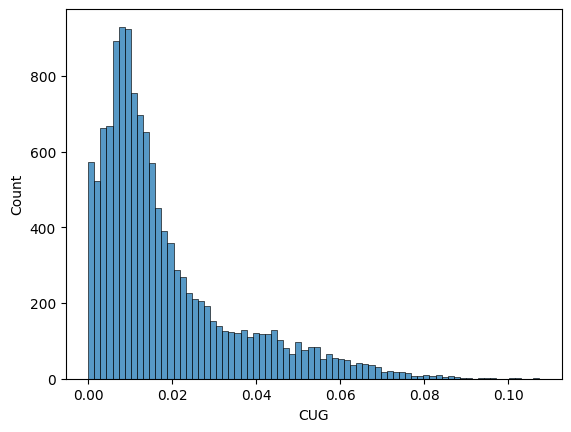

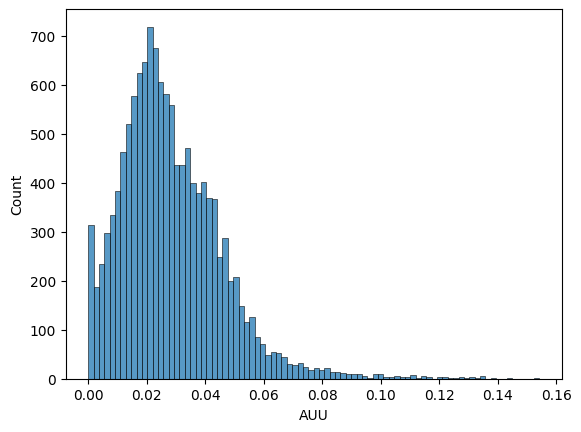

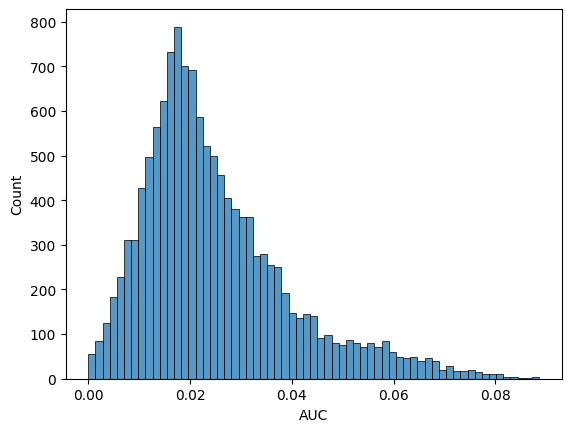

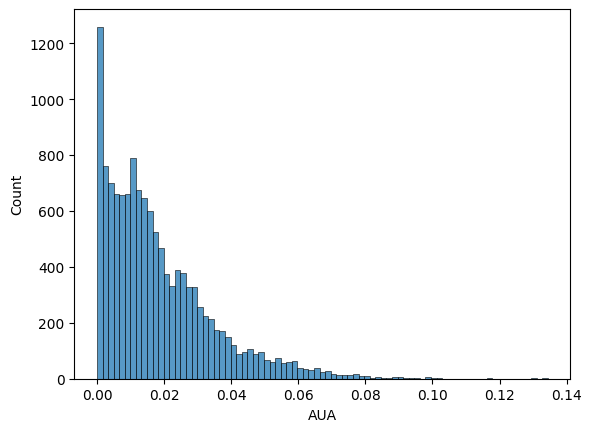

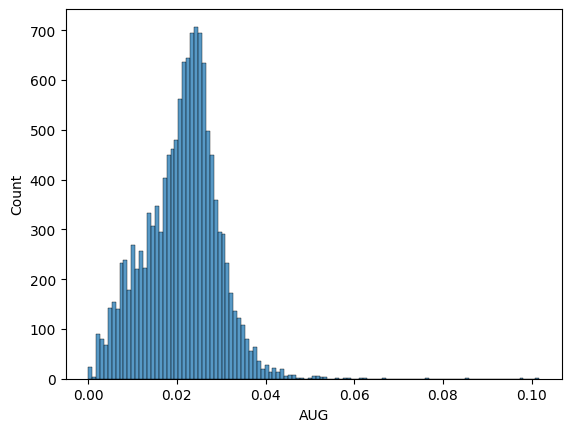

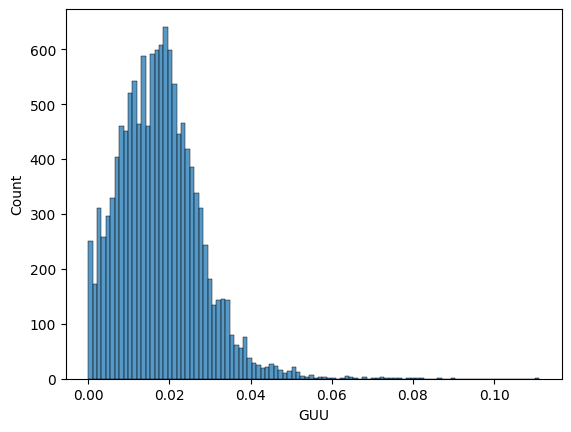

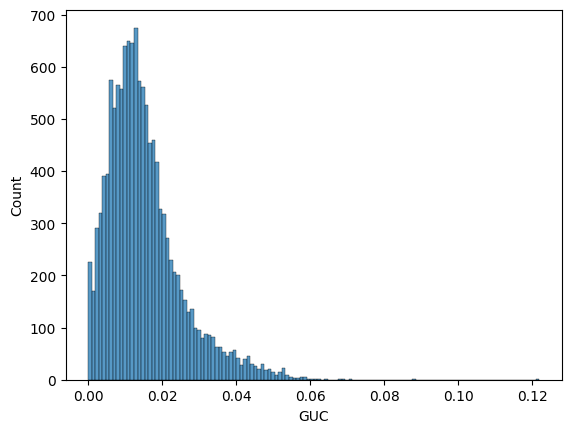

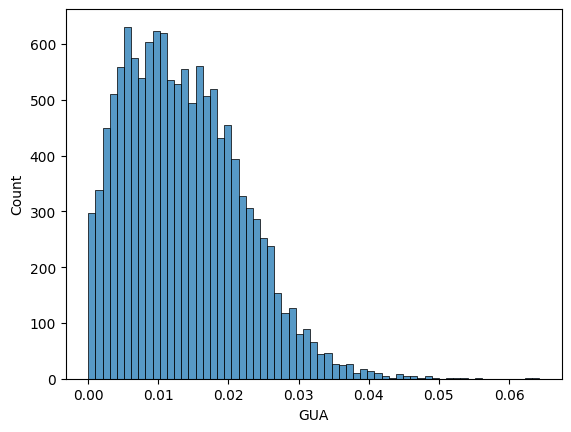

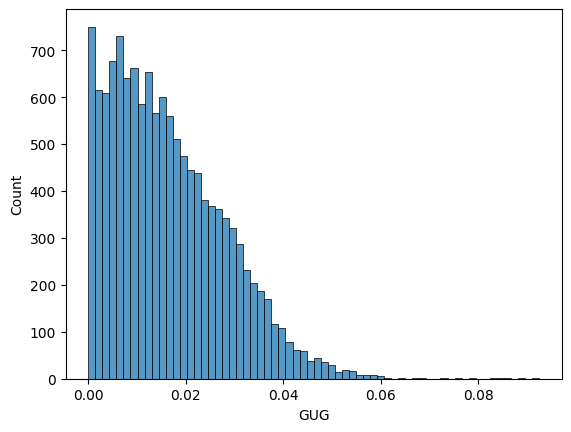

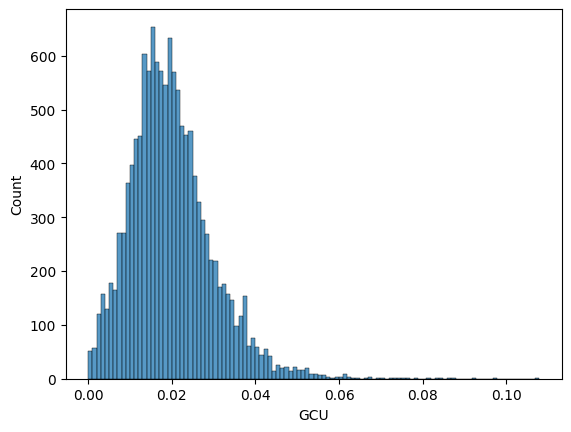

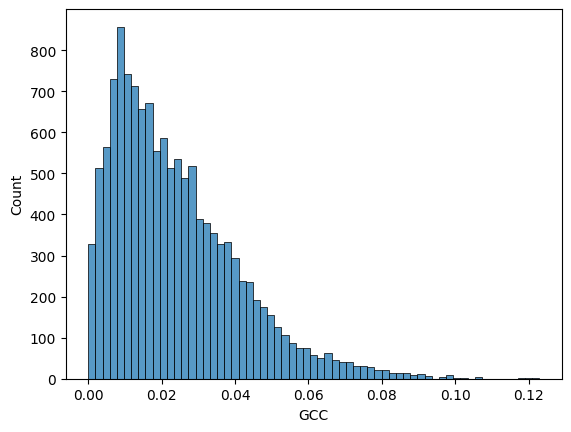

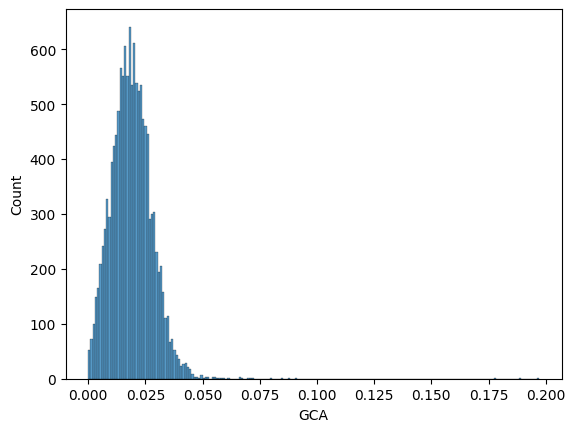

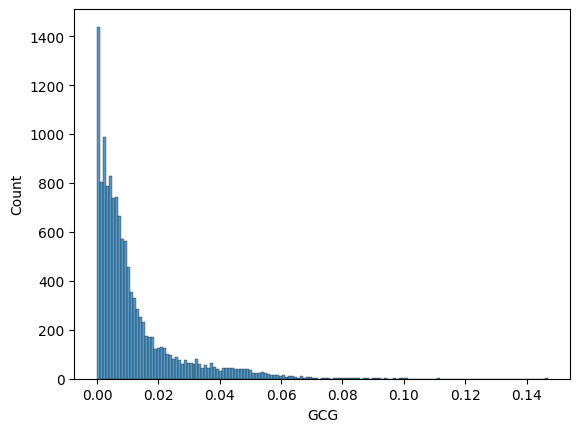

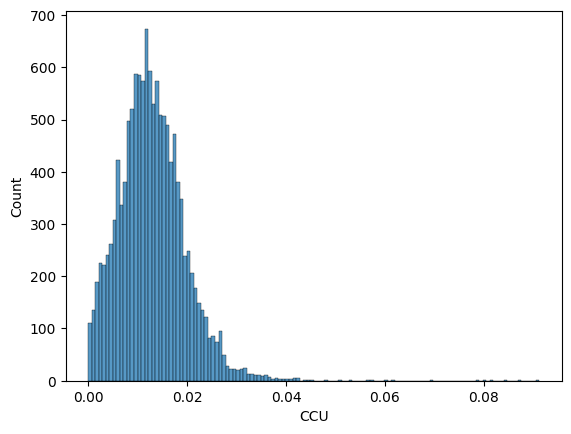

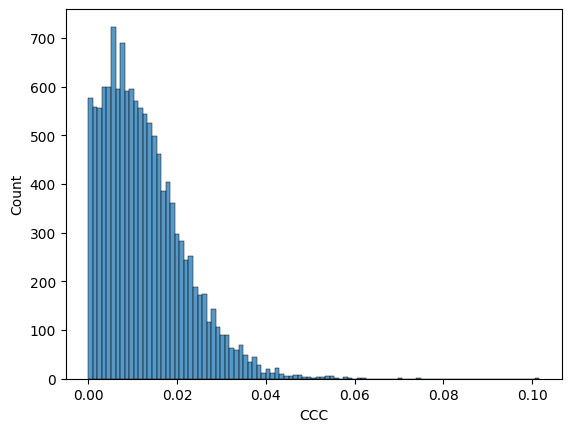

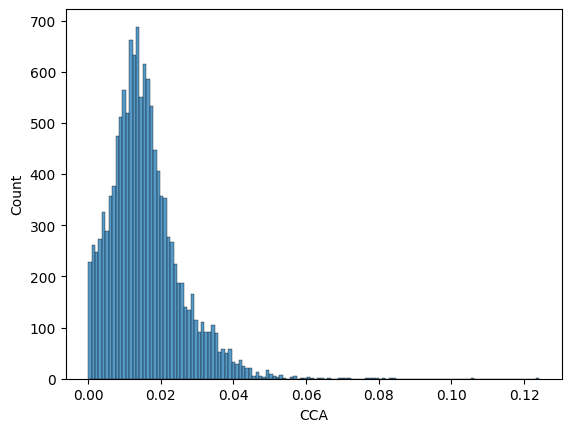

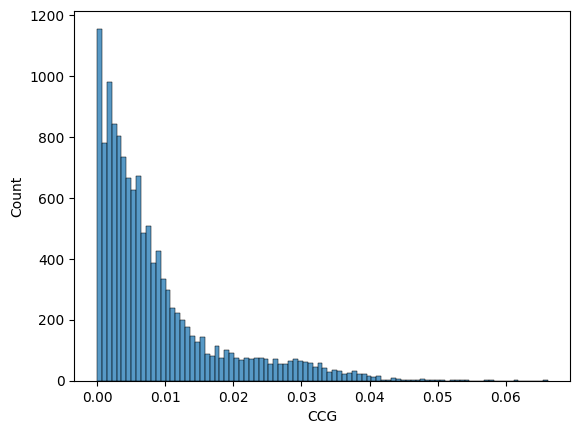

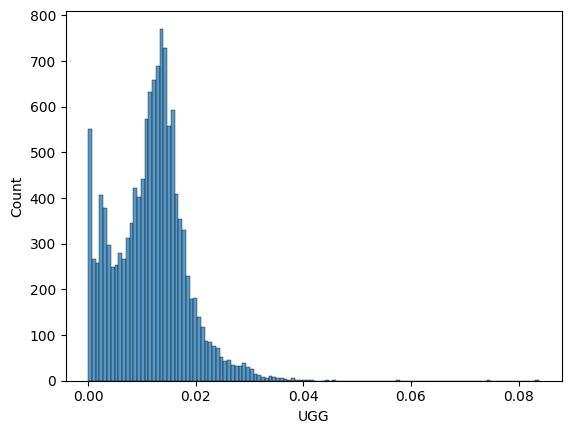

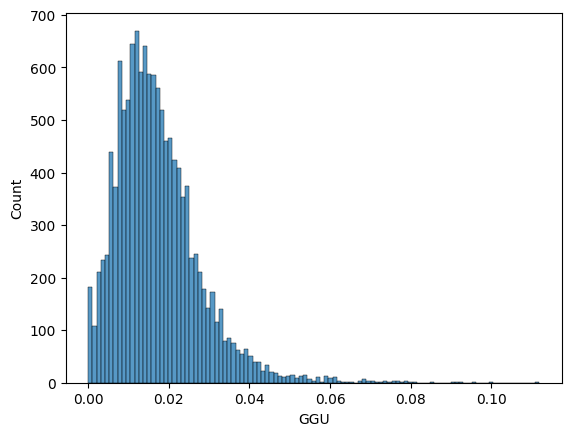

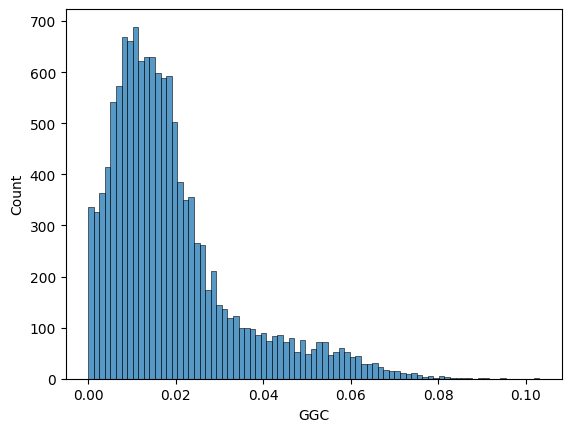

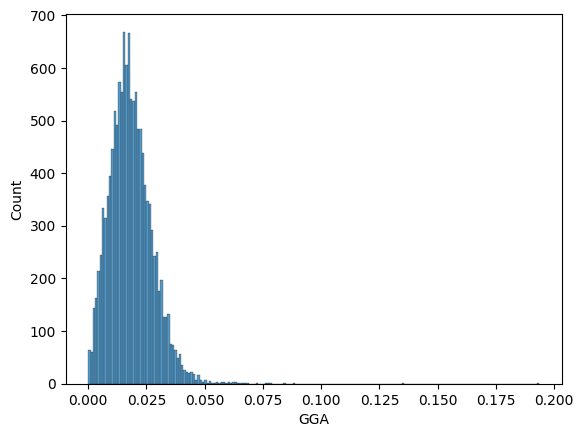

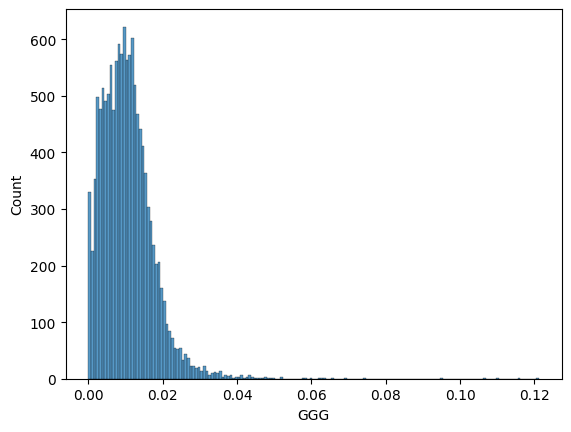

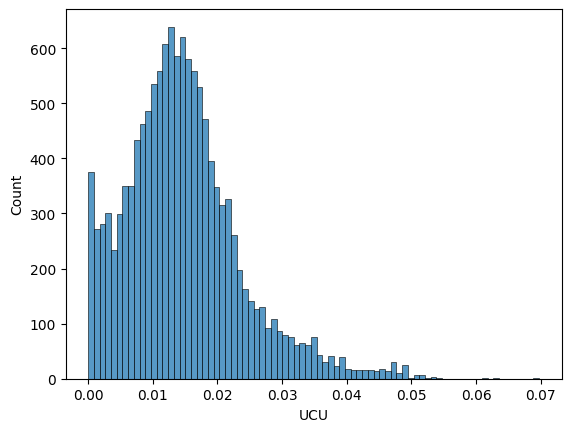

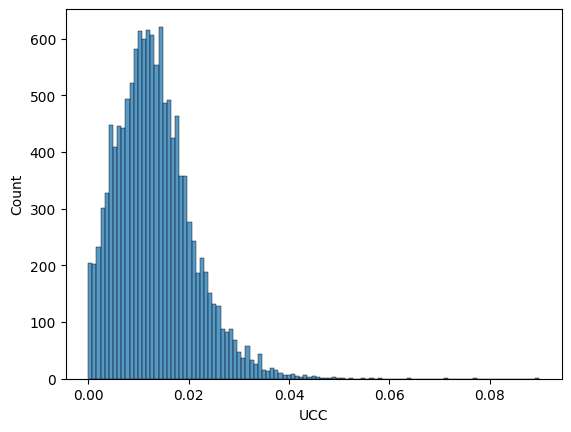

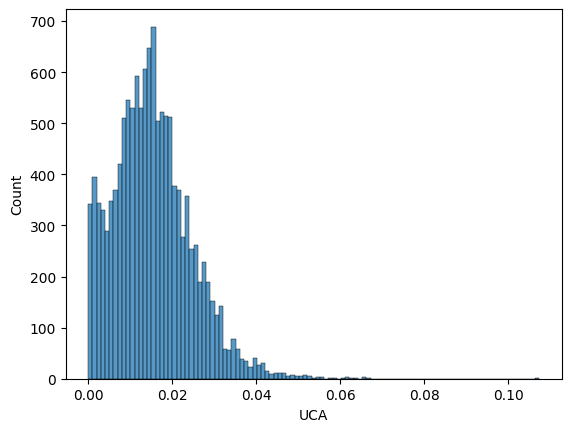

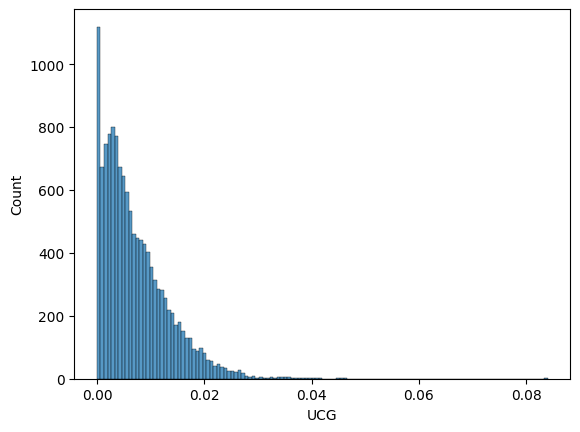

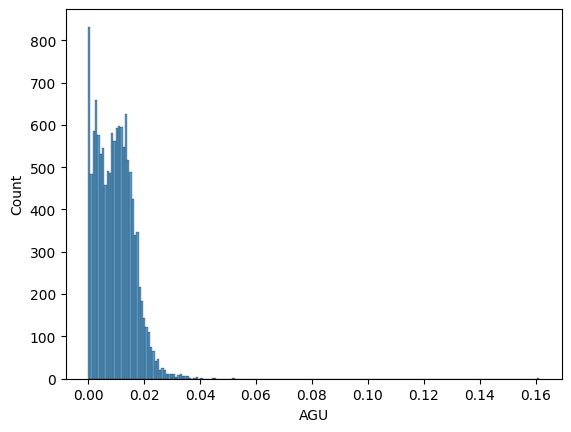

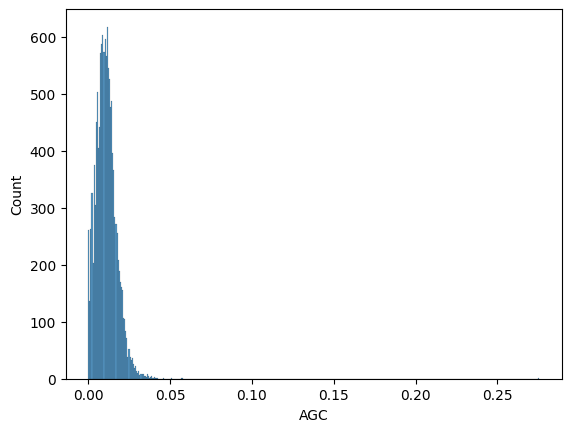

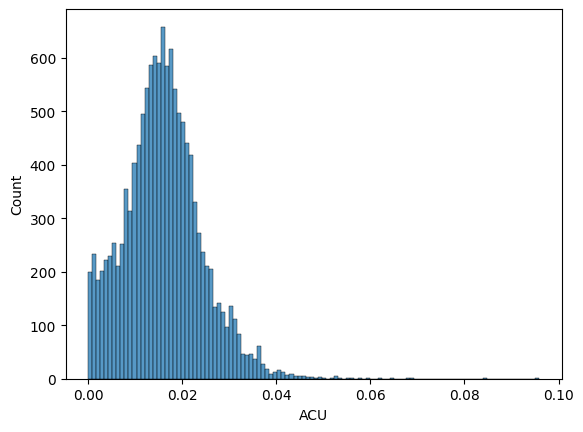

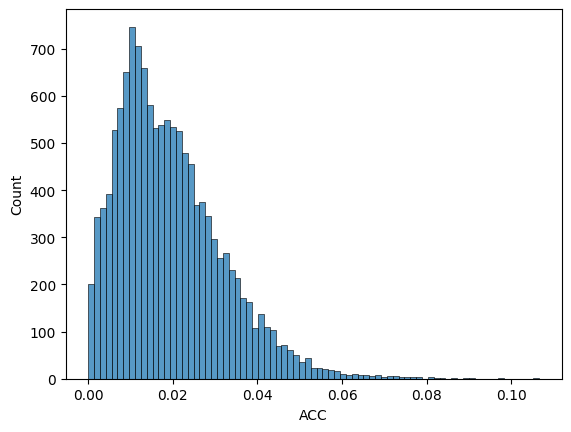

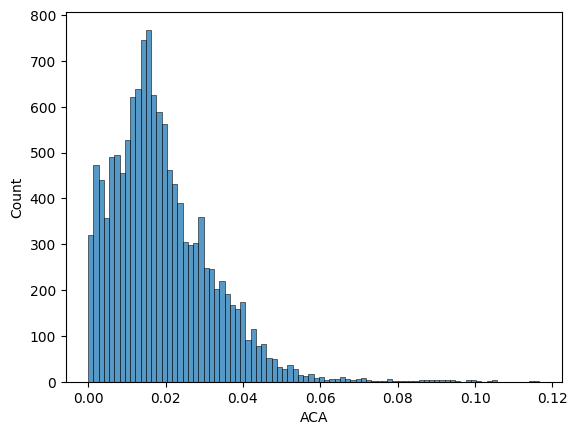

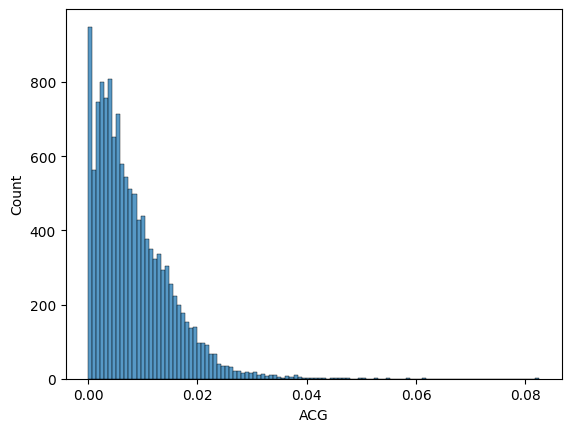

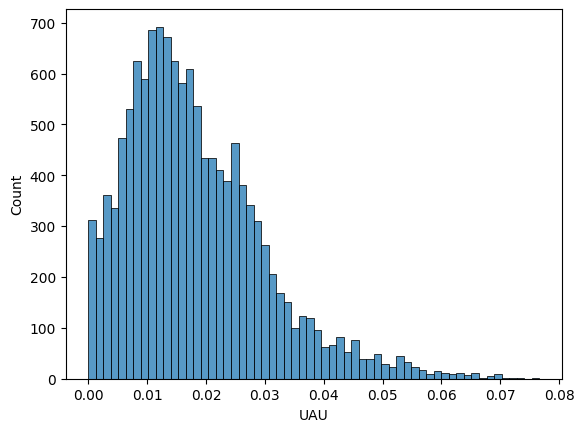

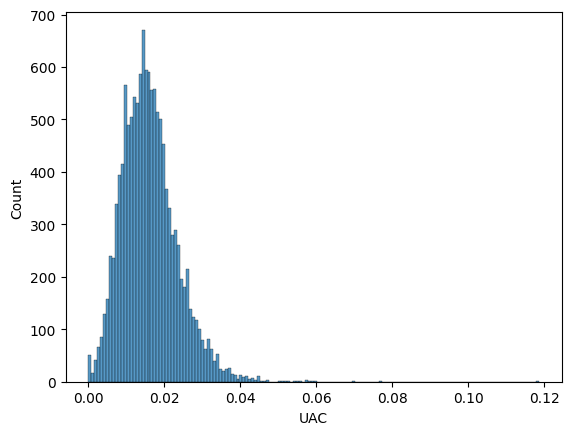

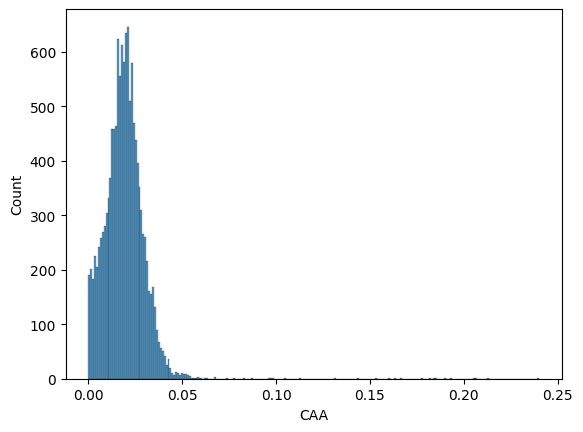

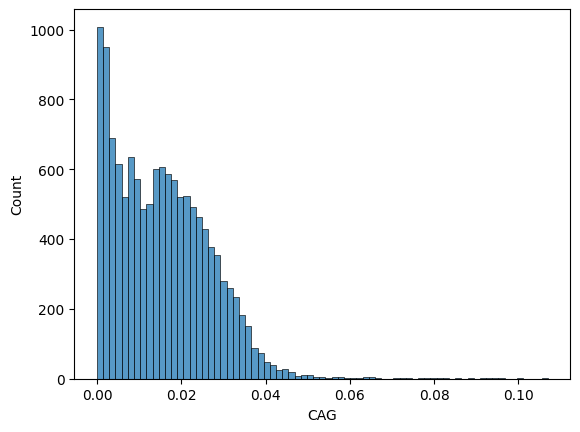

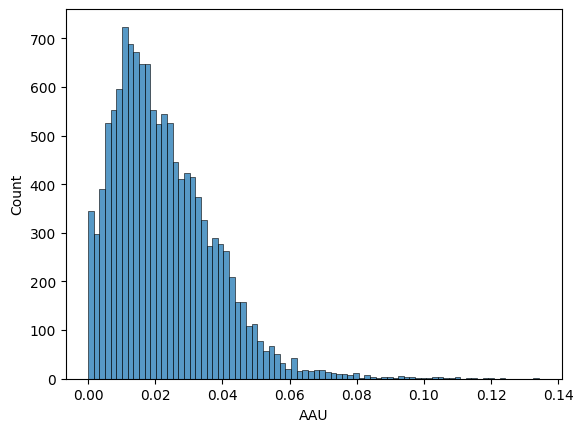

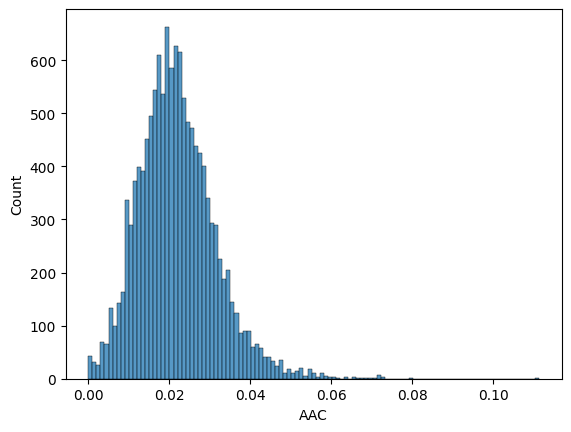

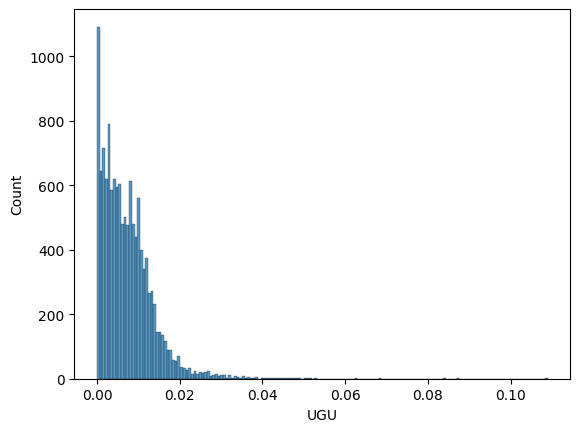

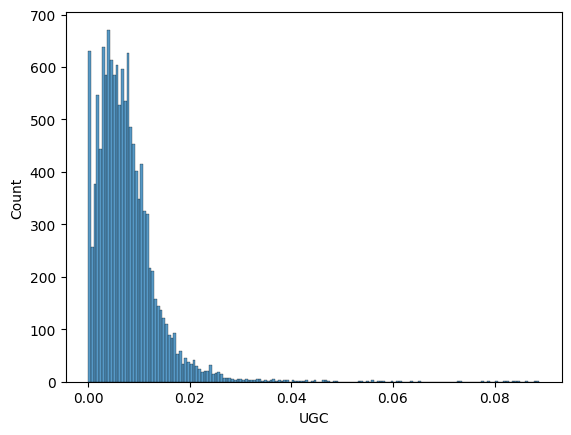

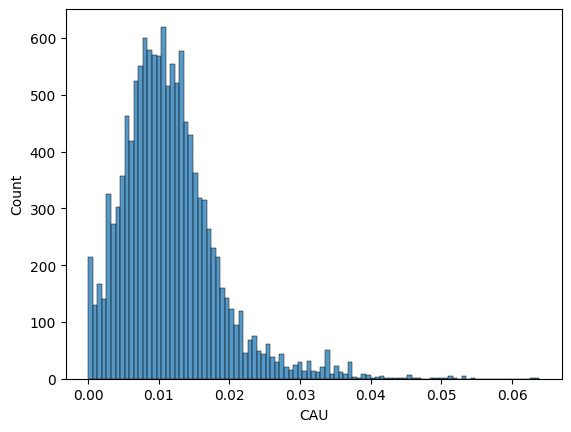

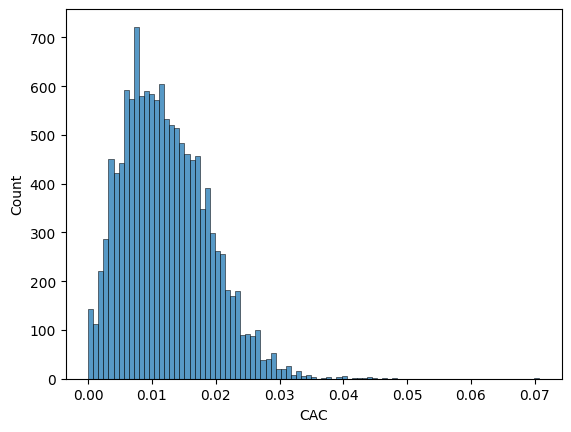

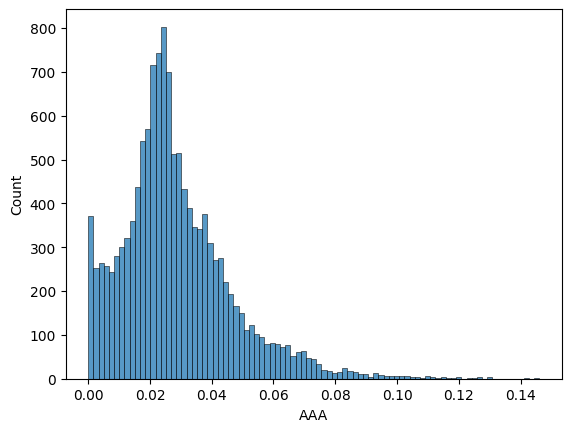

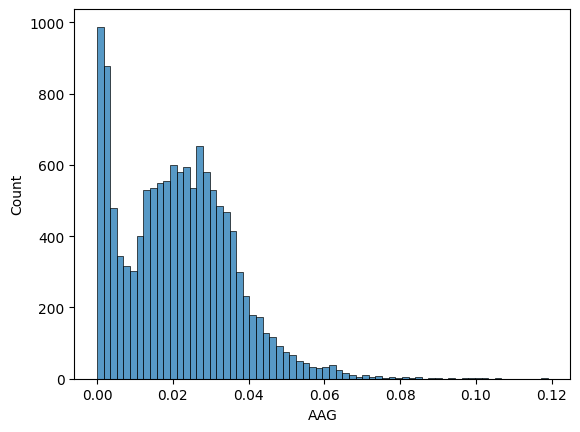

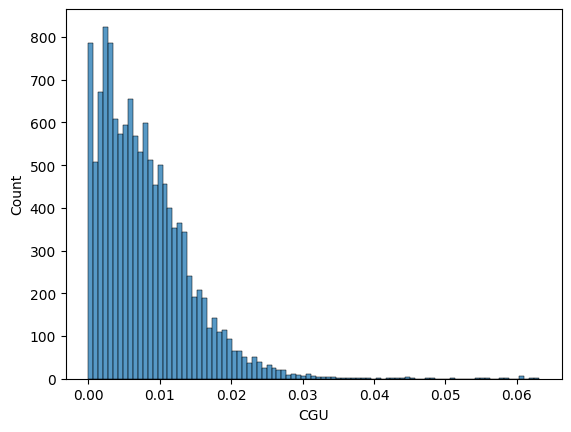

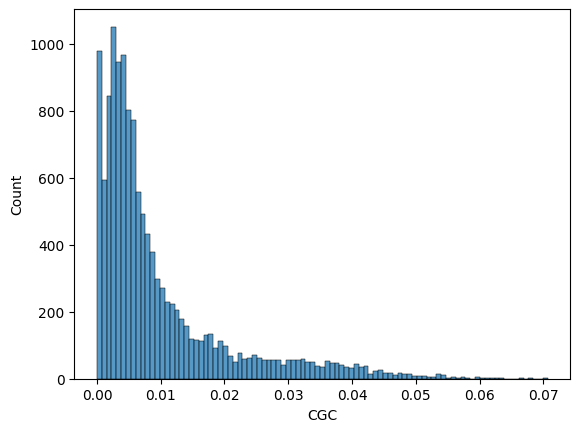

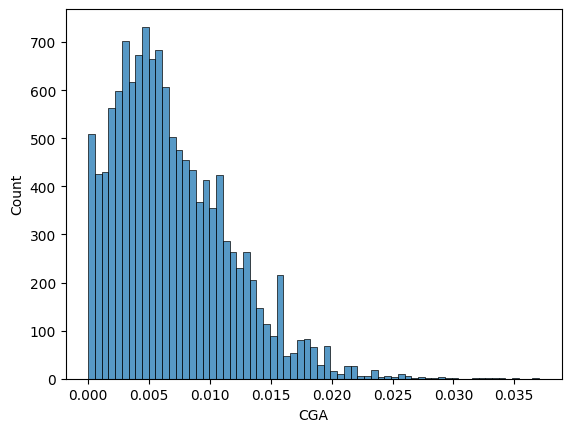

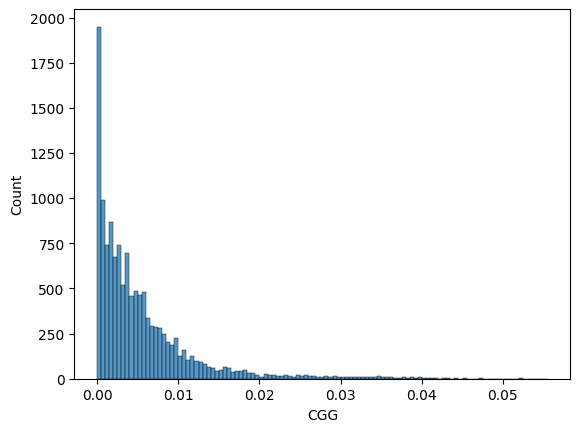

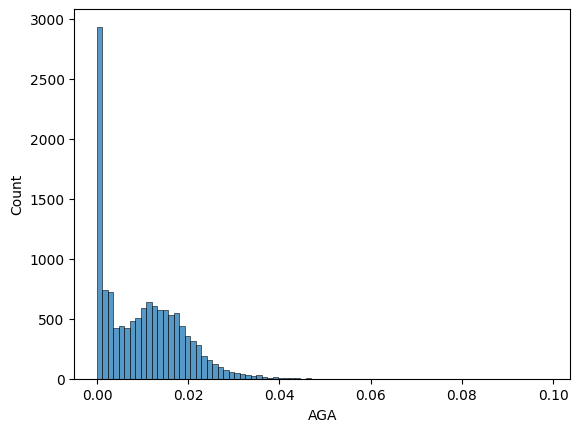

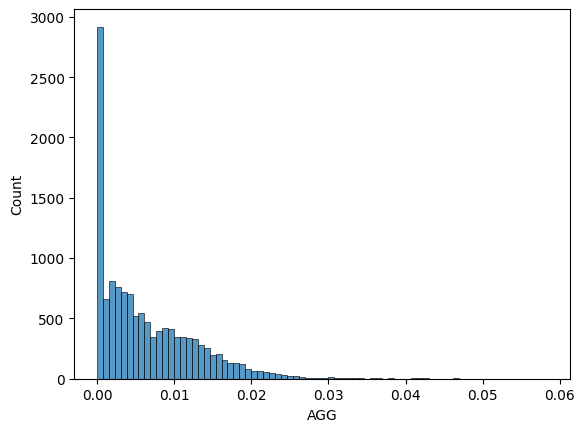

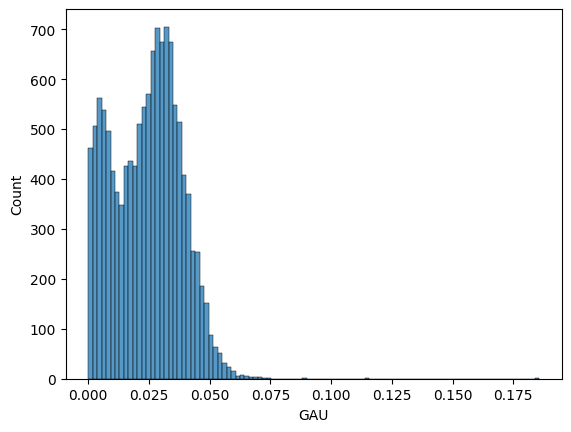

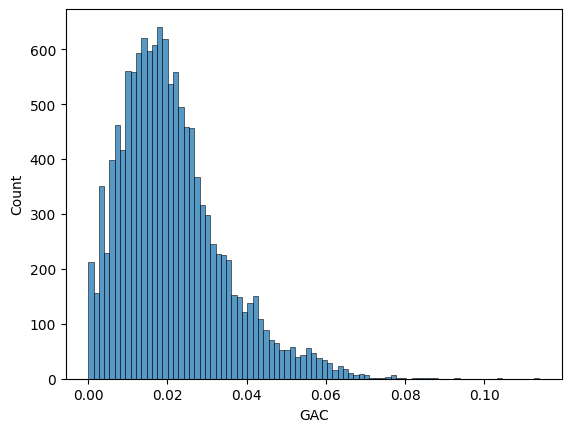

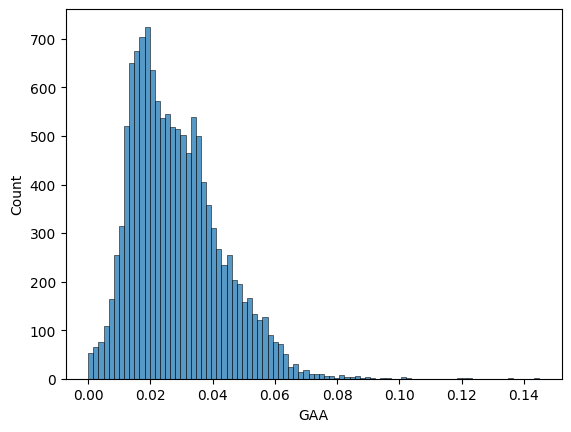

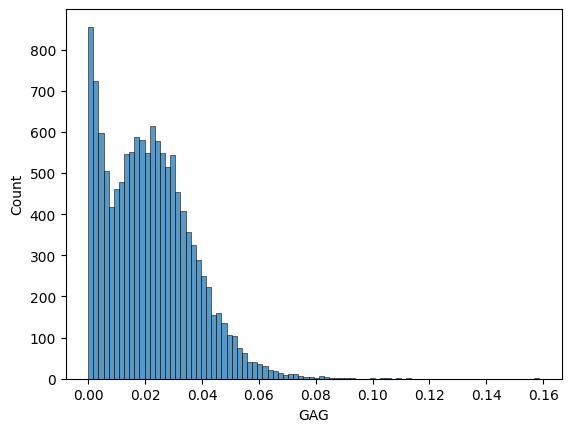

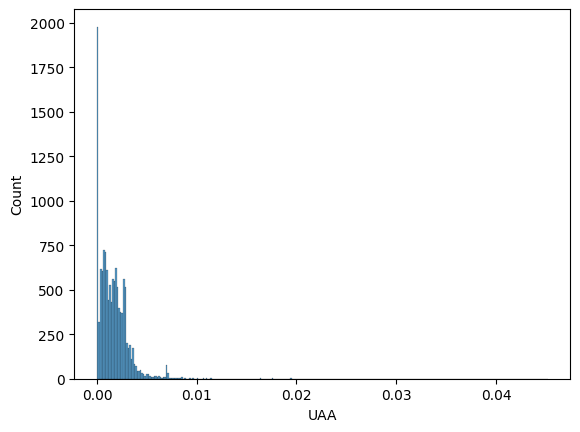

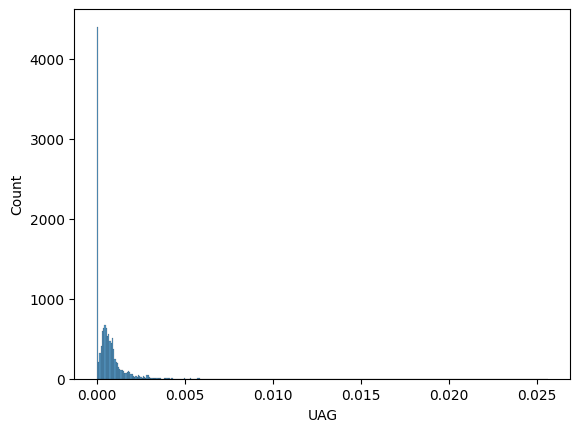

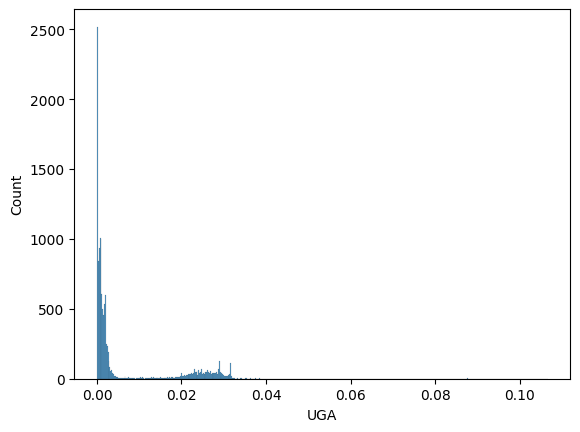

In [144]:
#Histograms
for i in df.select_dtypes(include = "number").columns:
  sns.histplot(data = df , x = i)
  plt.show()

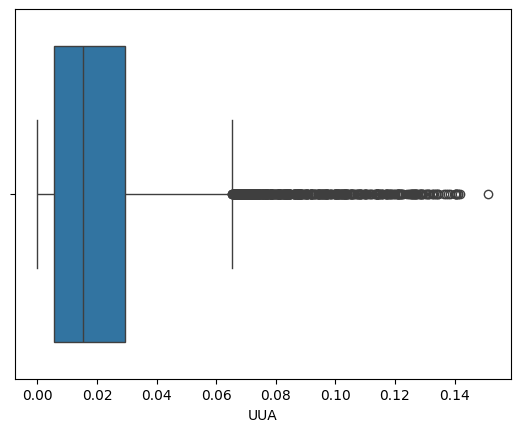

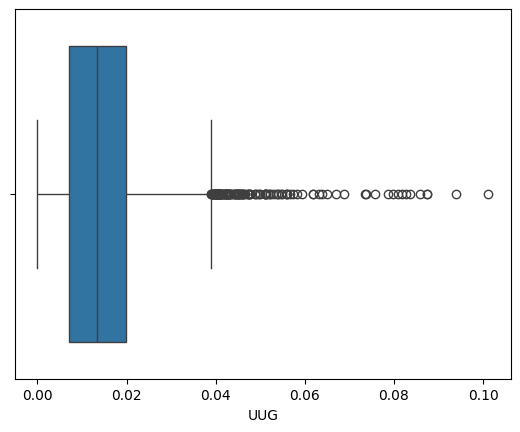

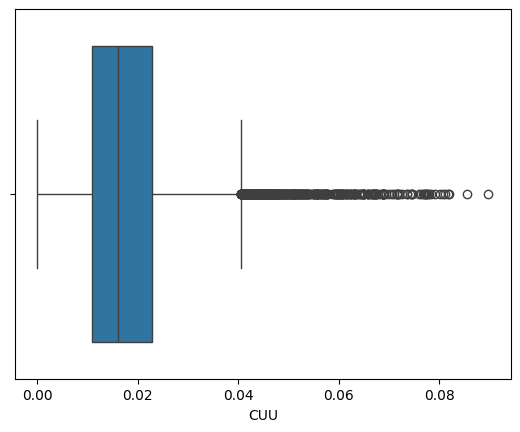

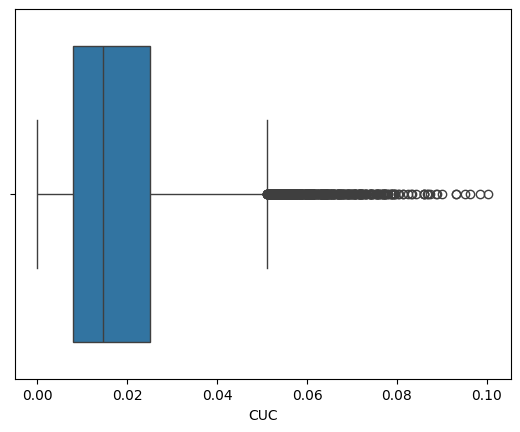

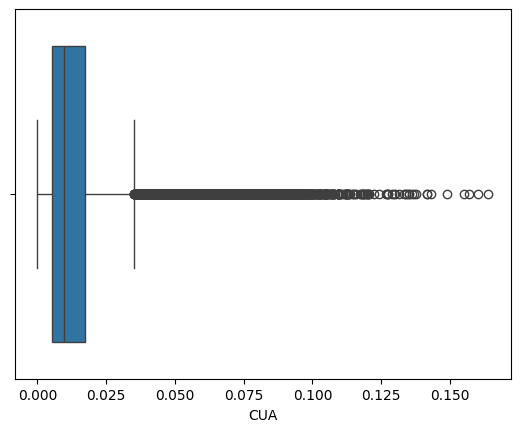

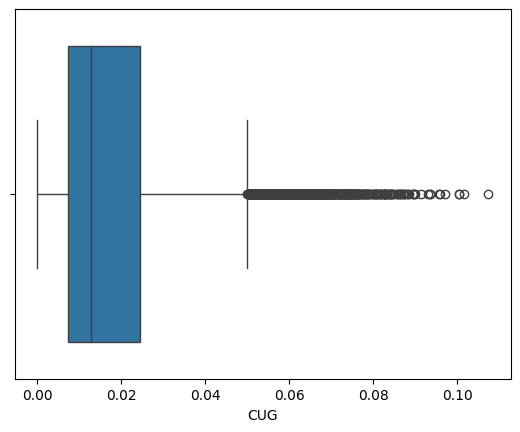

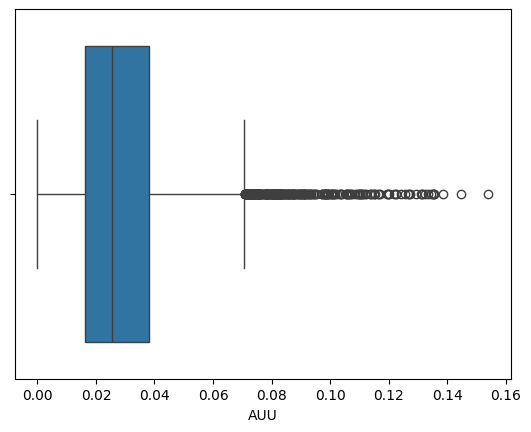

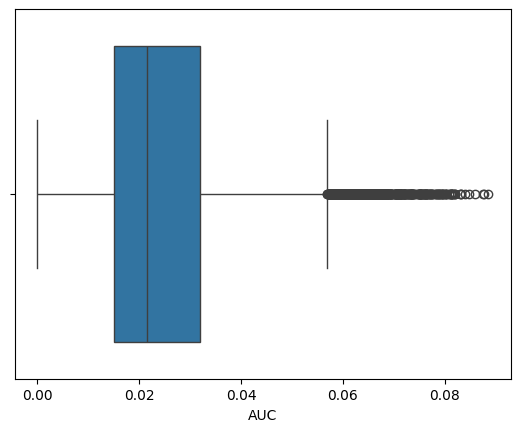

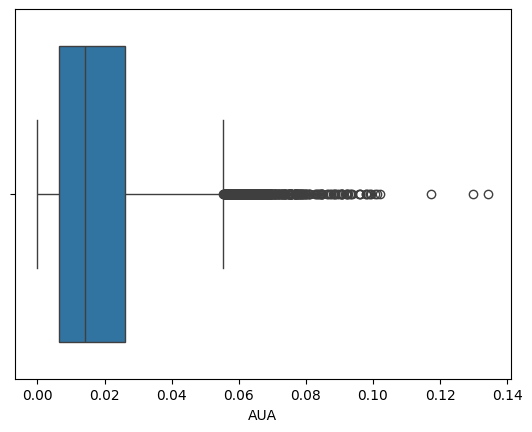

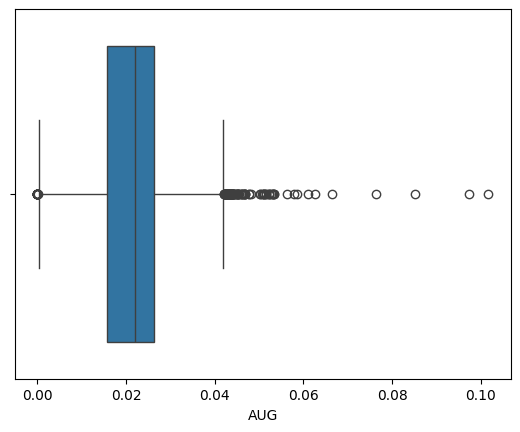

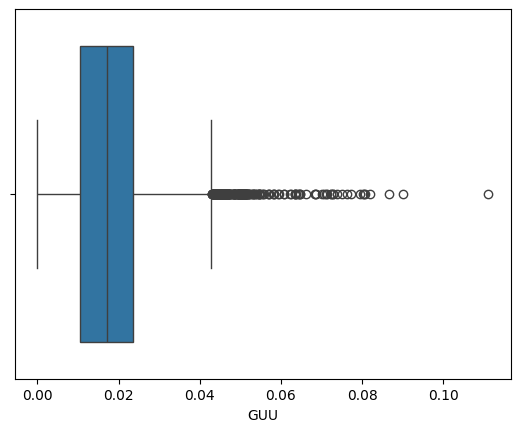

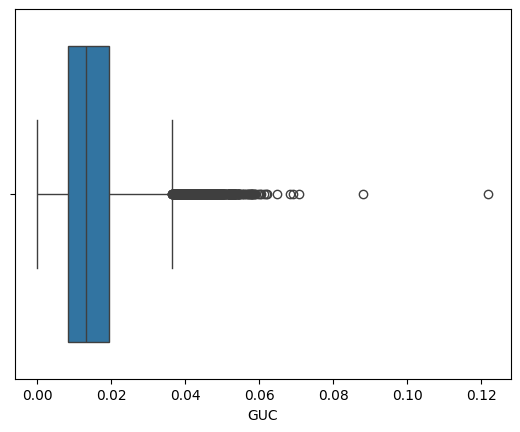

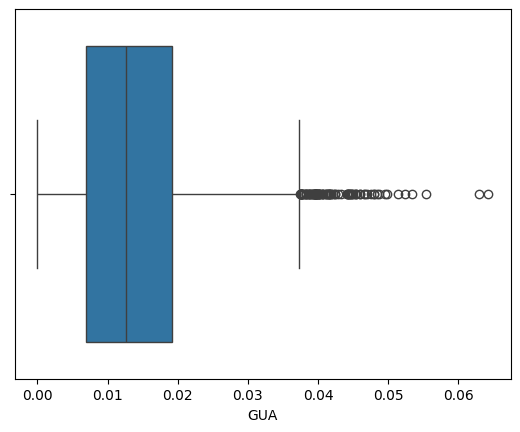

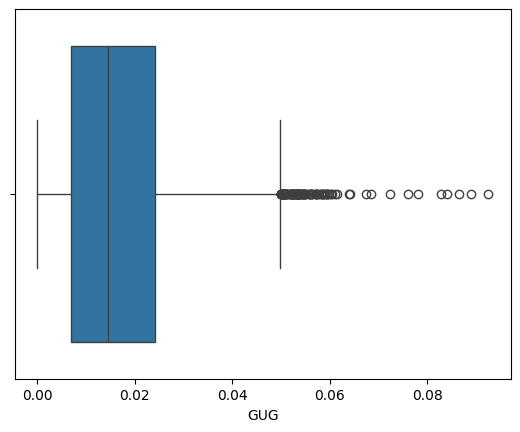

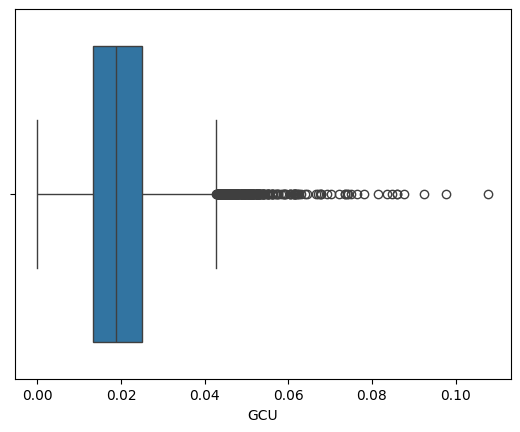

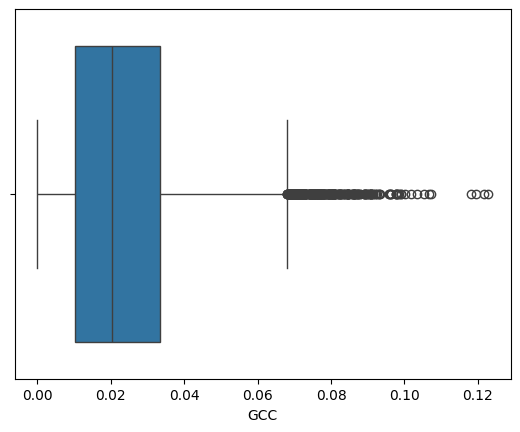

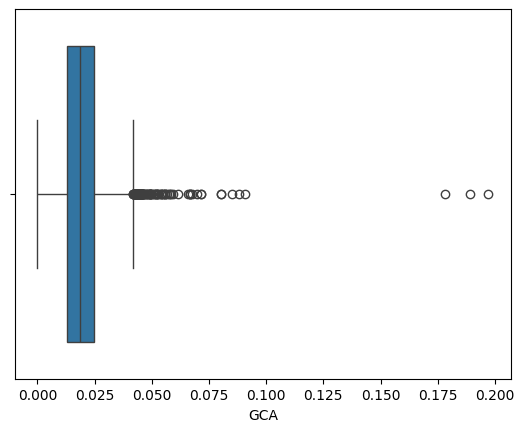

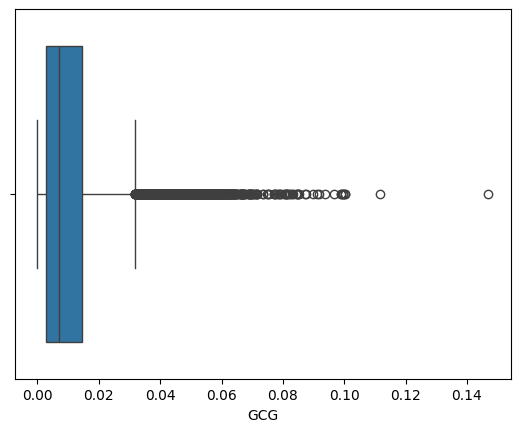

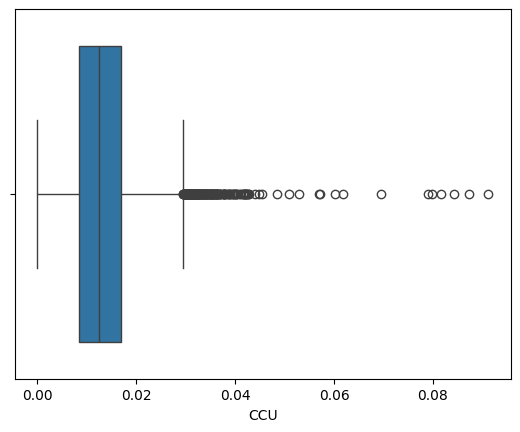

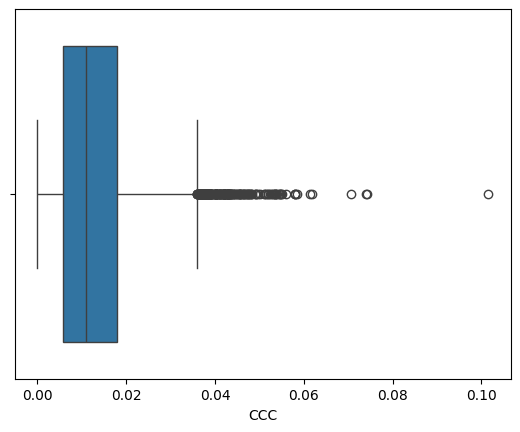

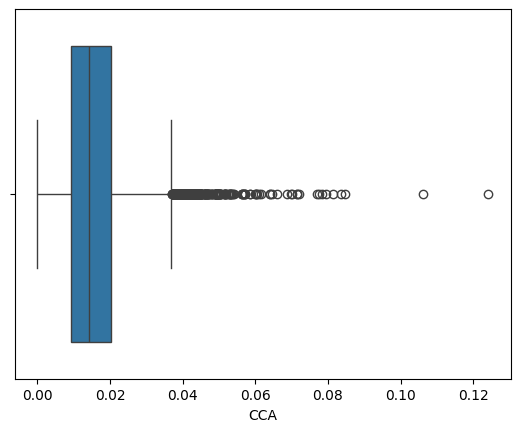

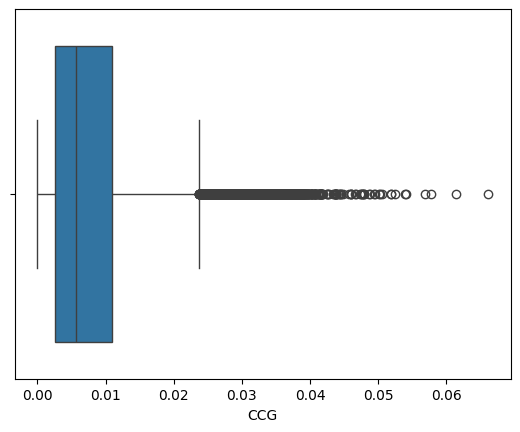

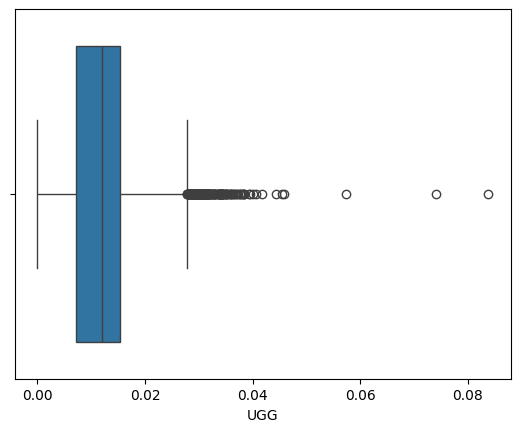

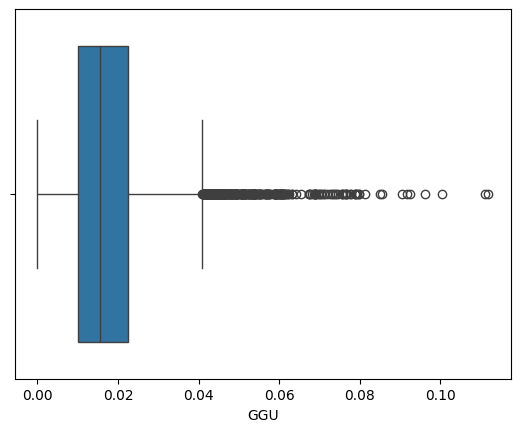

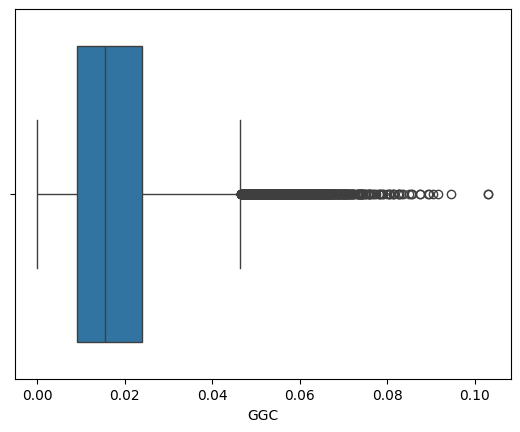

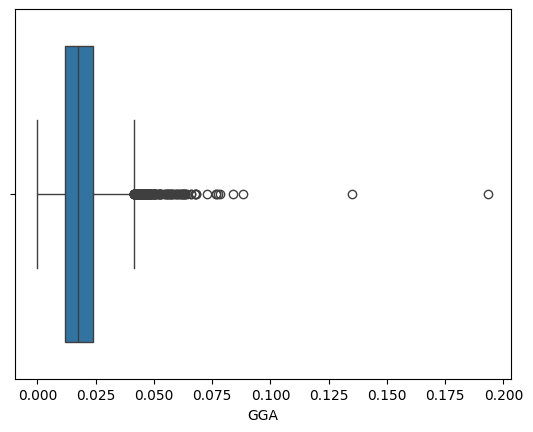

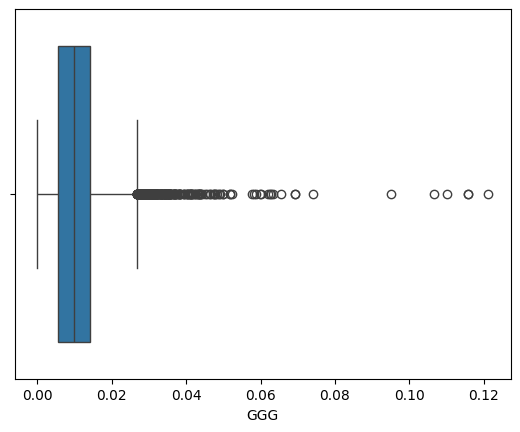

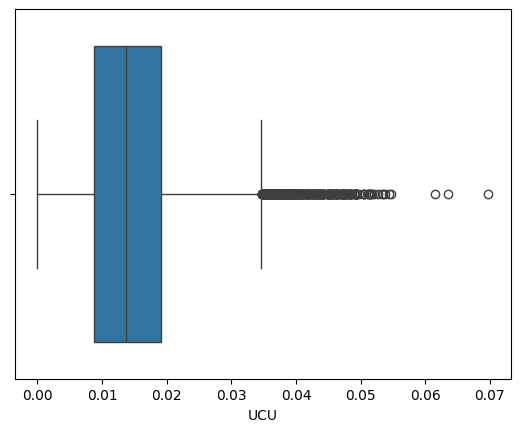

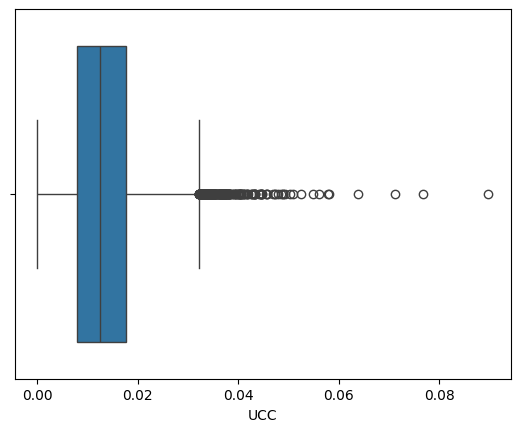

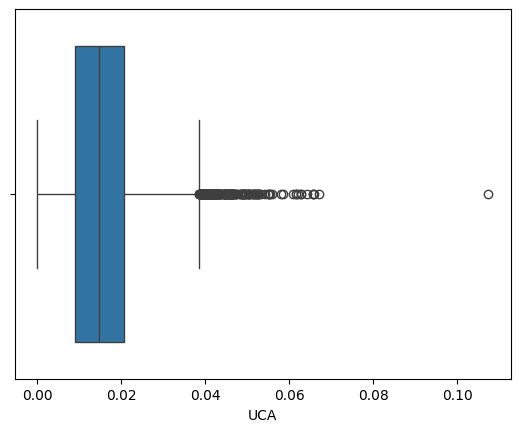

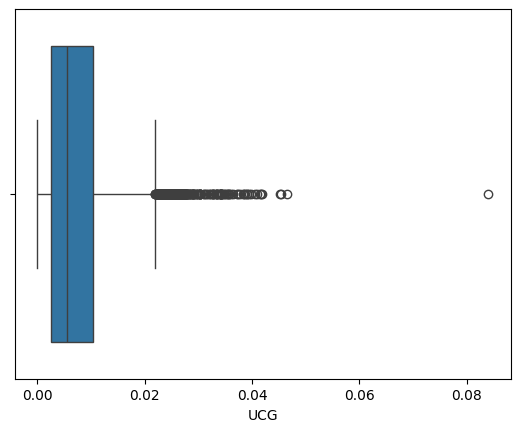

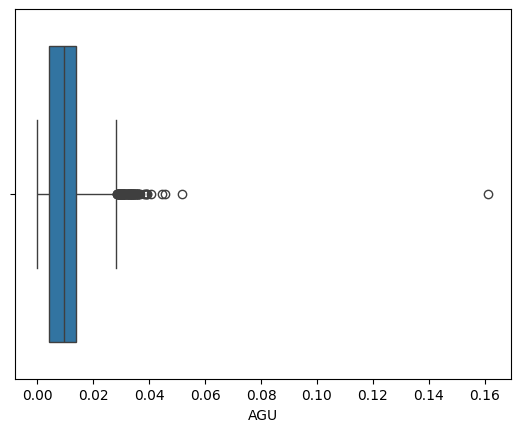

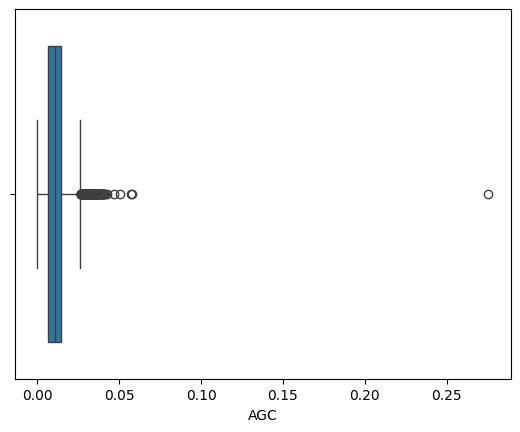

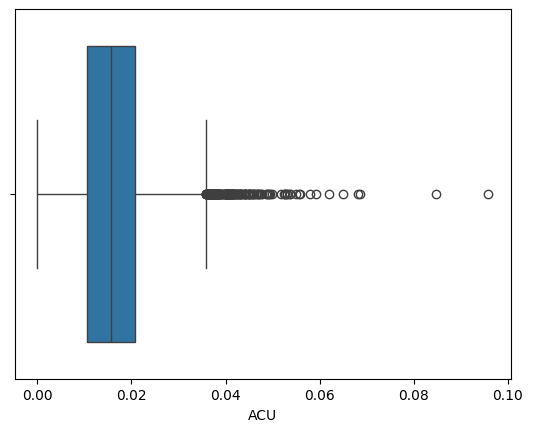

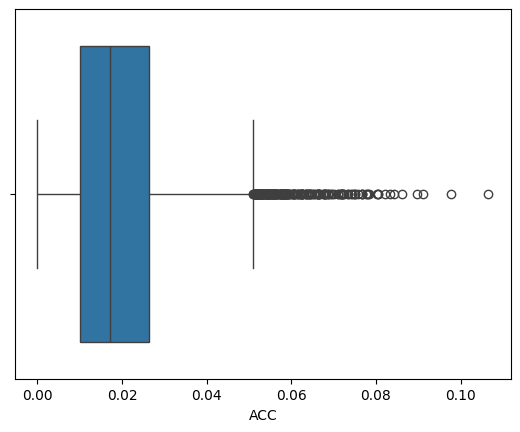

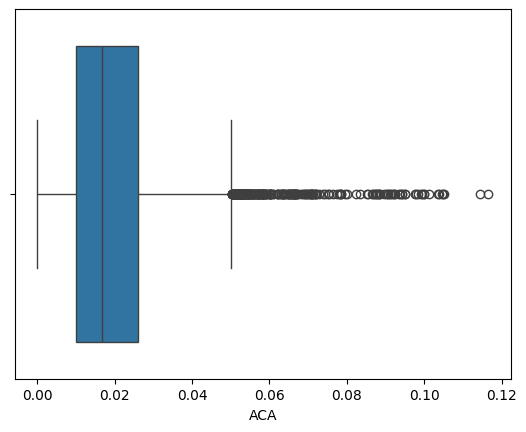

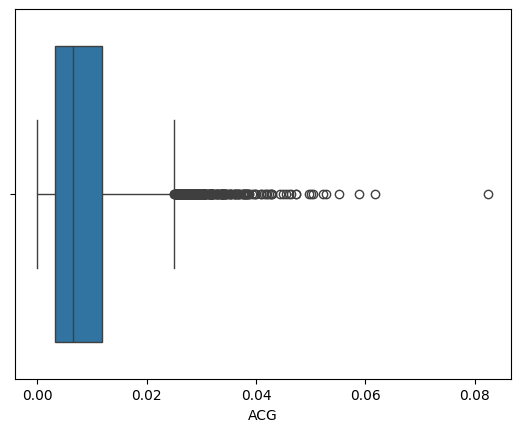

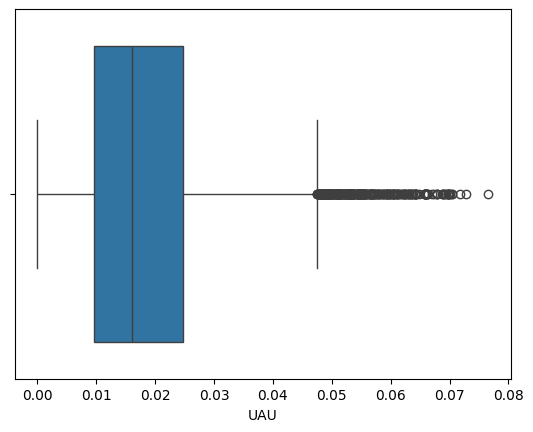

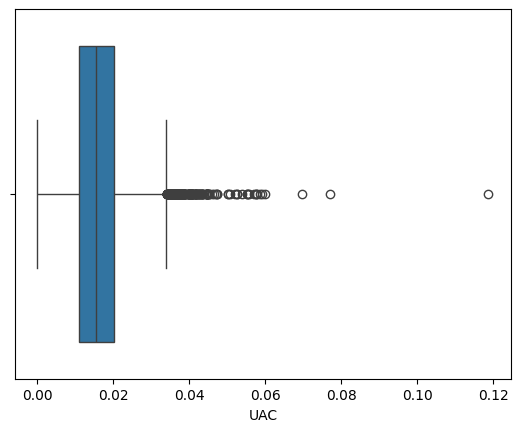

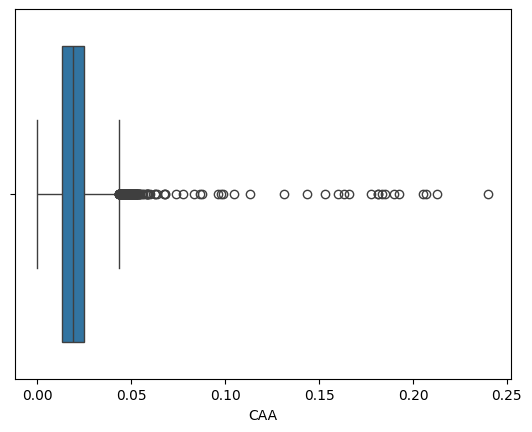

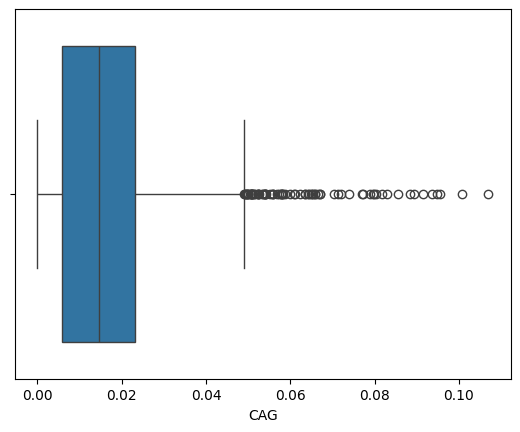

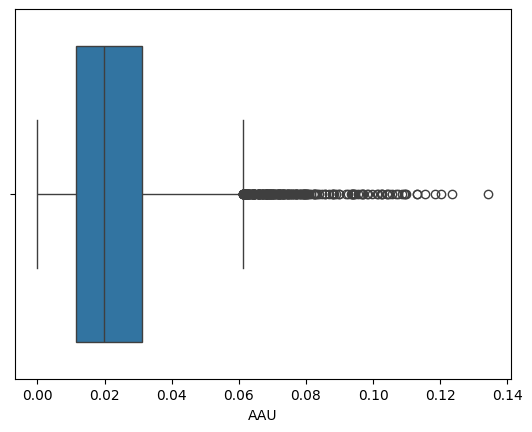

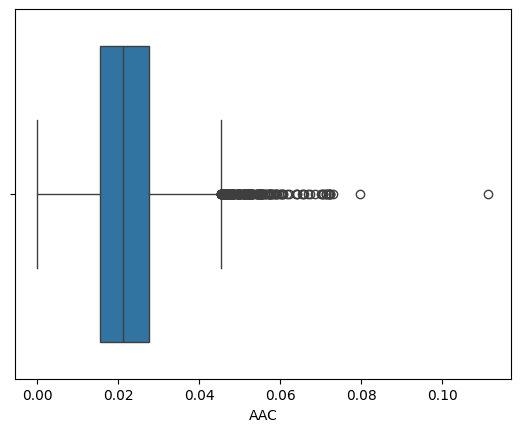

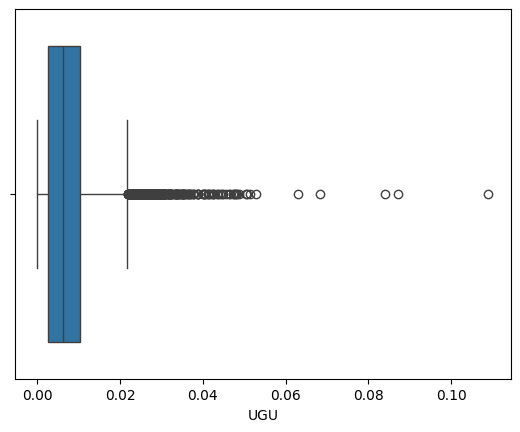

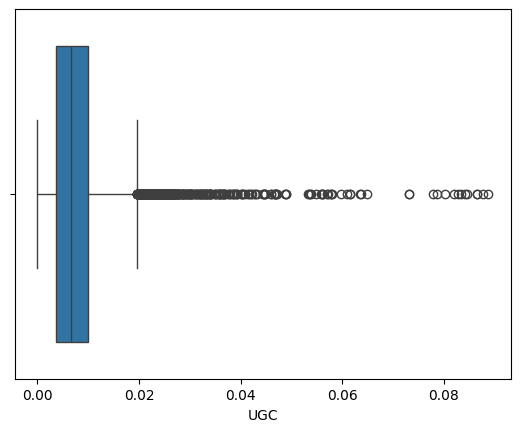

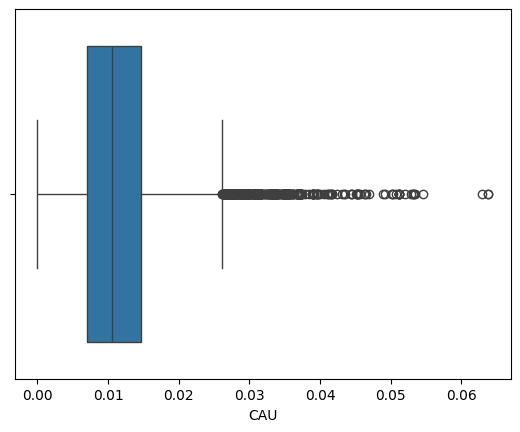

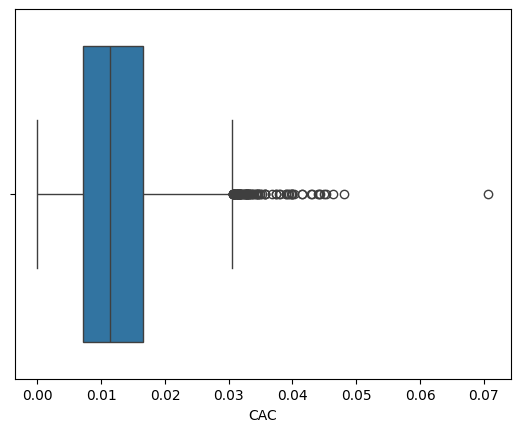

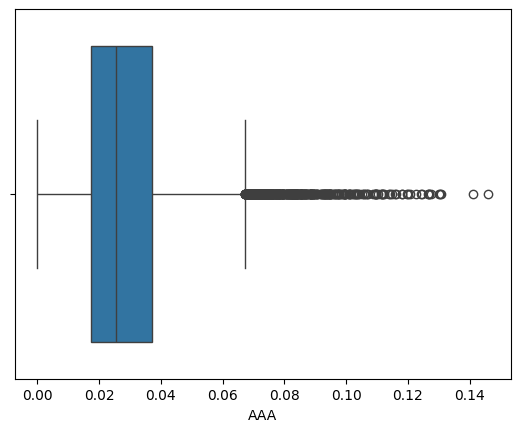

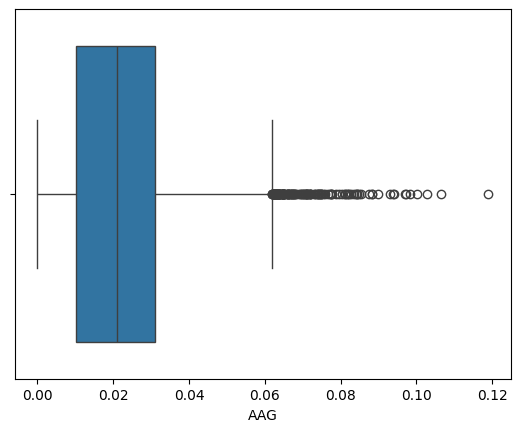

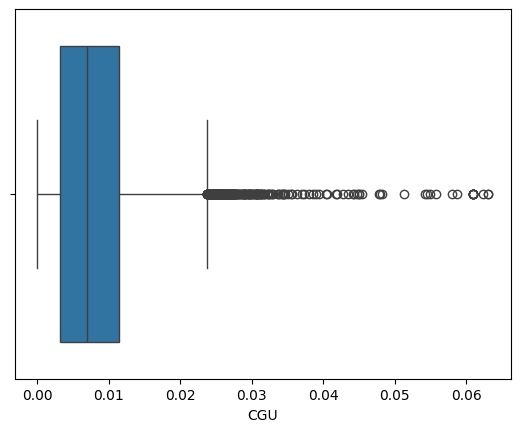

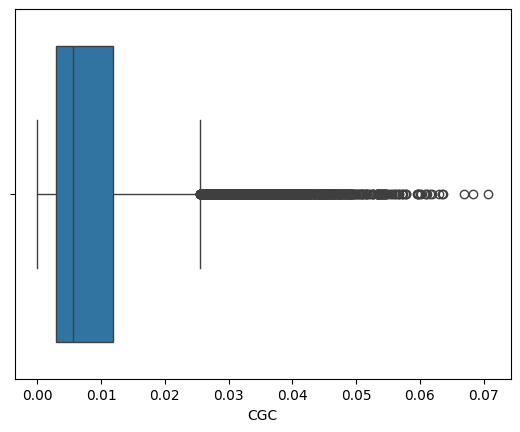

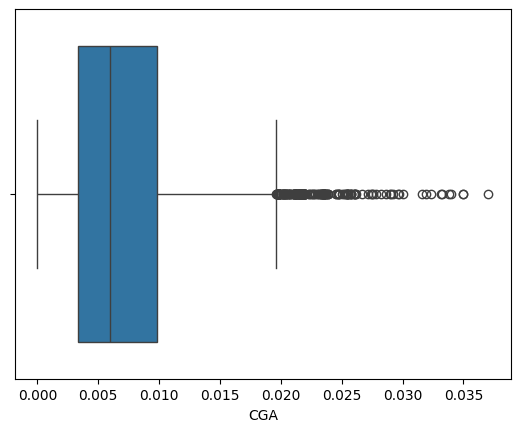

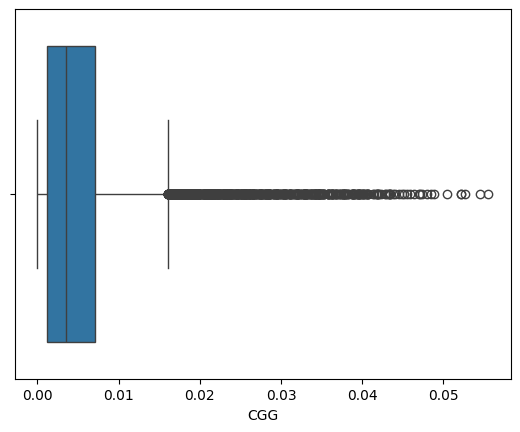

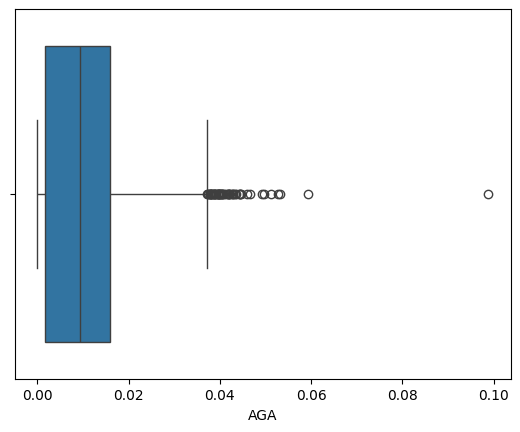

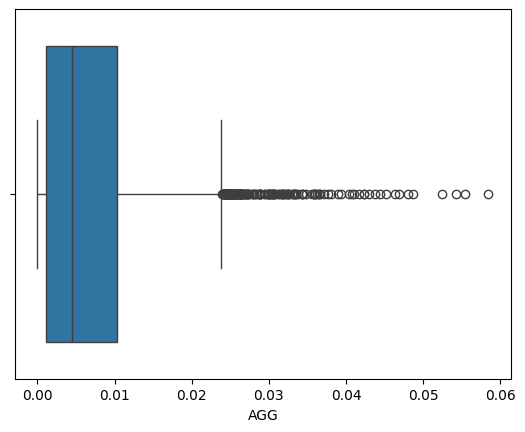

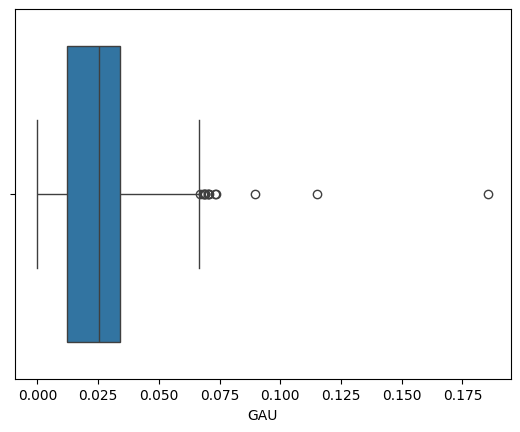

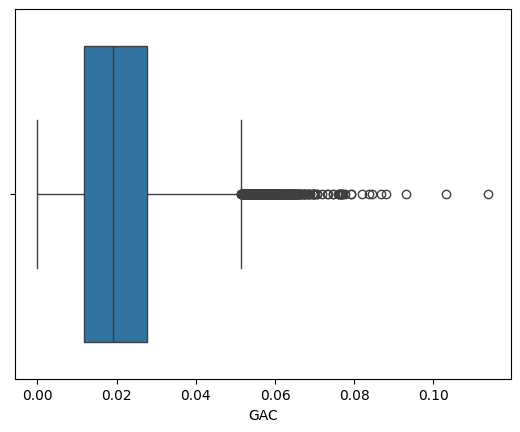

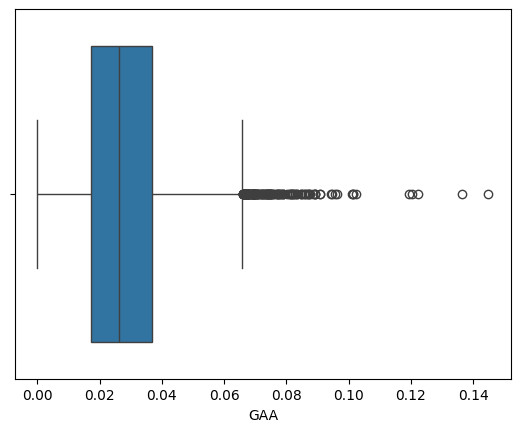

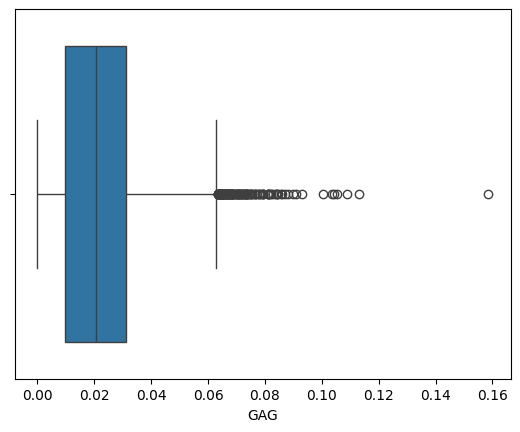

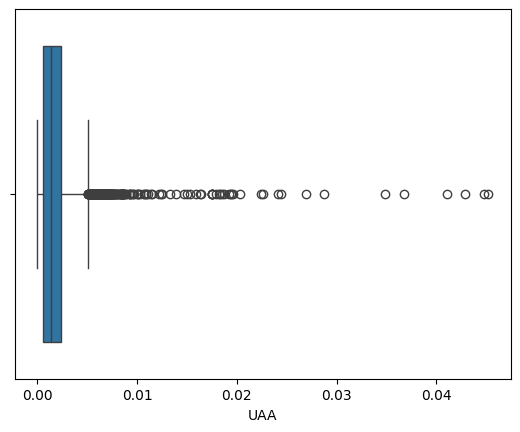

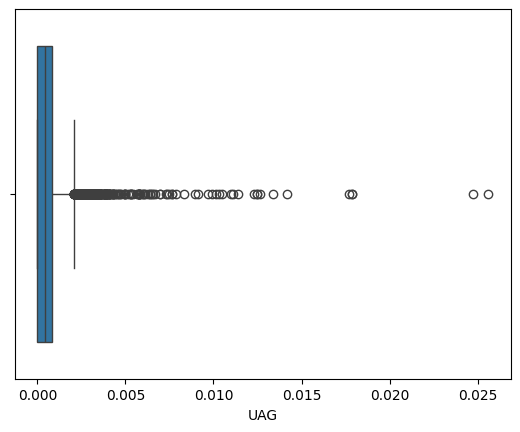

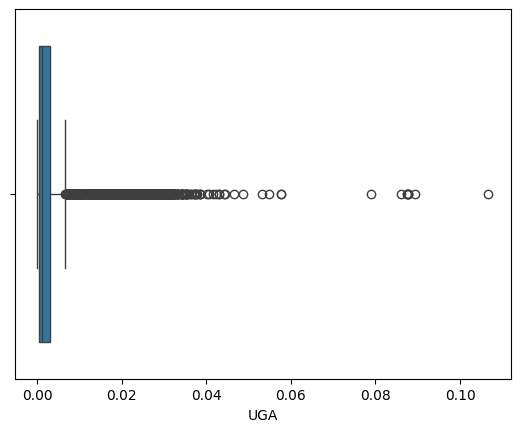

In [145]:
#BoxPlots
for i in df.select_dtypes(include = "number").columns:
  sns.boxplot(data = df , x = i)
  plt.show()

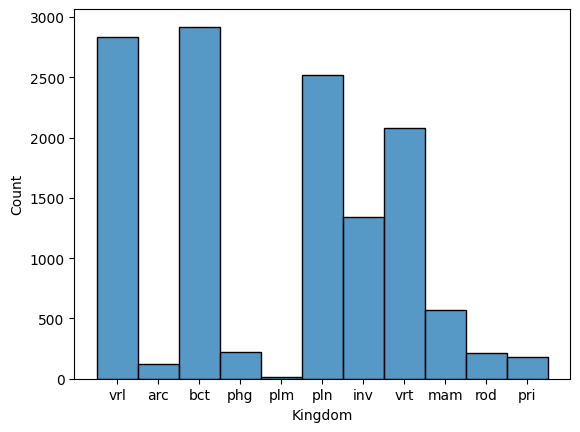

In [146]:
#Showing the distribution of the target variable
sns.histplot(data = df , x = "Kingdom")
plt.show()

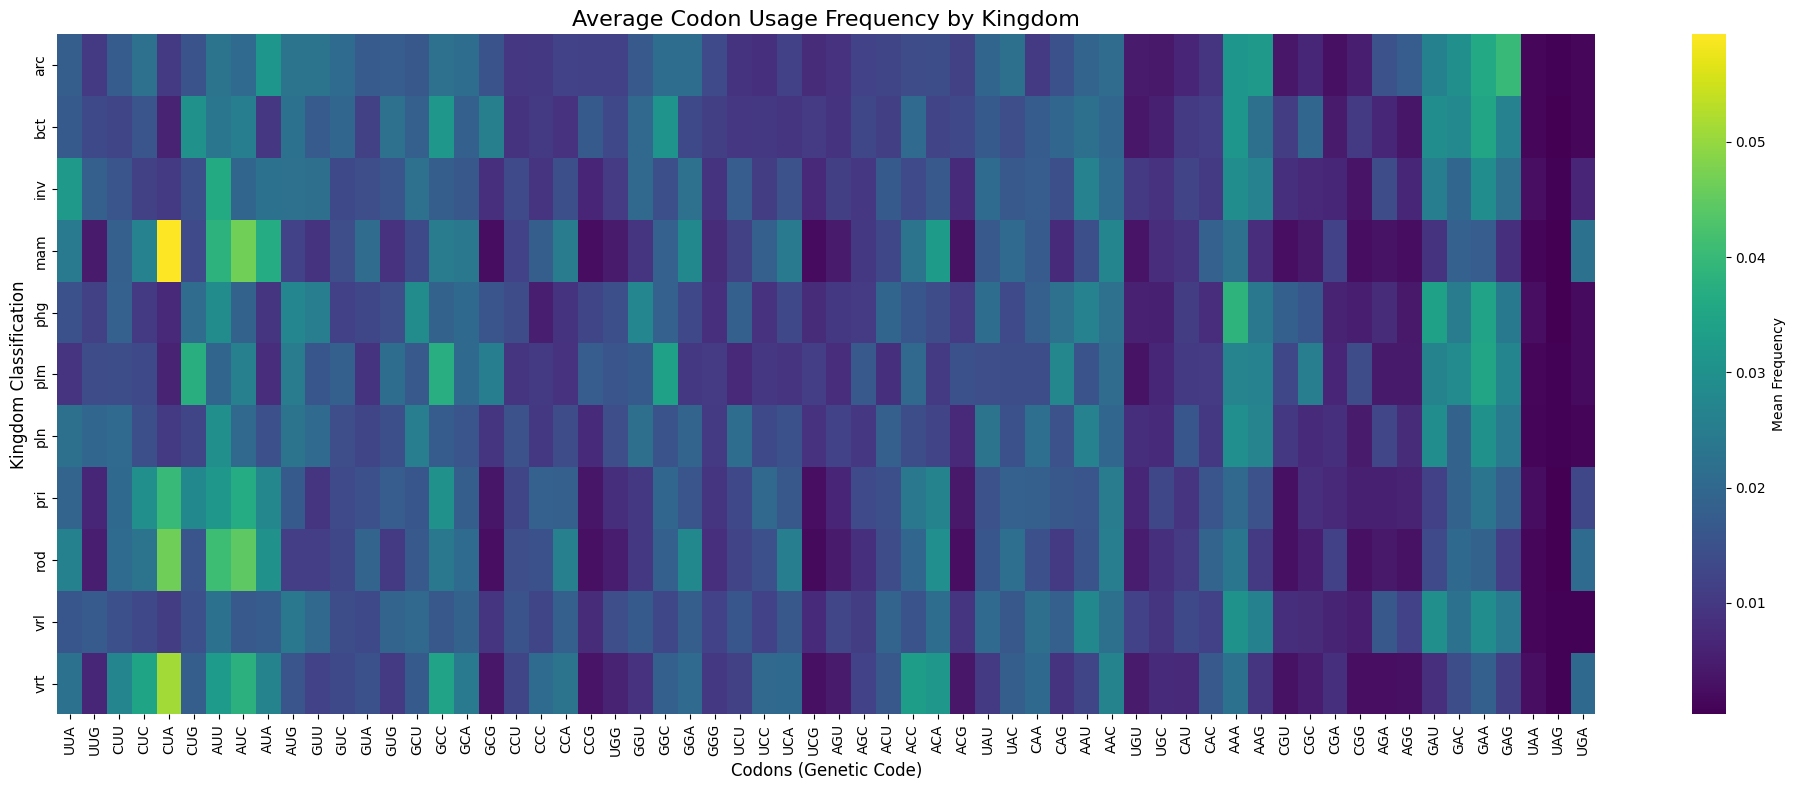

In [147]:
kingdom_means = df.groupby('Kingdom')[['UUA', 'UUG', 'CUU', 'CUC', 'CUA', 'CUG', 'AUU', 'AUC',
       'AUA', 'AUG', 'GUU', 'GUC', 'GUA', 'GUG', 'GCU', 'GCC', 'GCA', 'GCG',
       'CCU', 'CCC', 'CCA', 'CCG', 'UGG', 'GGU', 'GGC', 'GGA', 'GGG', 'UCU',
       'UCC', 'UCA', 'UCG', 'AGU', 'AGC', 'ACU', 'ACC', 'ACA', 'ACG', 'UAU',
       'UAC', 'CAA', 'CAG', 'AAU', 'AAC', 'UGU', 'UGC', 'CAU', 'CAC', 'AAA',
       'AAG', 'CGU', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG', 'GAU', 'GAC', 'GAA',
       'GAG', 'UAA', 'UAG', 'UGA']].mean()
plt.figure(figsize=(20, 8))
sns.heatmap(
    kingdom_means,
    cmap='viridis',
    annot=False,
    cbar_kws={'label': 'Mean Frequency'}
)

plt.title('Average Codon Usage Frequency by Kingdom', fontsize=16)
plt.xlabel('Codons (Genetic Code)', fontsize=12)
plt.ylabel('Kingdom Classification', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Handling class imbalance

In [148]:
#Grouping classes that are sub-groups of other class
df['Kingdom'] = df['Kingdom'].replace(['pri', 'rod'], 'mam')
#Deleting "plm" class which has very few data points
df = df[df['Kingdom'] != 'plm']

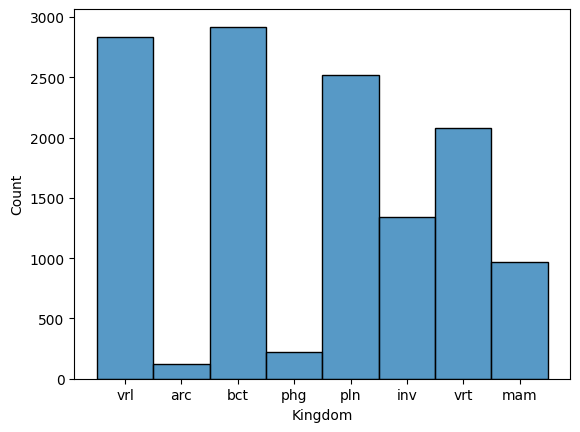

In [149]:
sns.histplot(data = df , x = "Kingdom")
plt.show()

# Applying PCA for Dimensionality reduction

In [150]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#Scaling the features
X = df[df.select_dtypes(include = "number").columns]
y = df['Kingdom']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

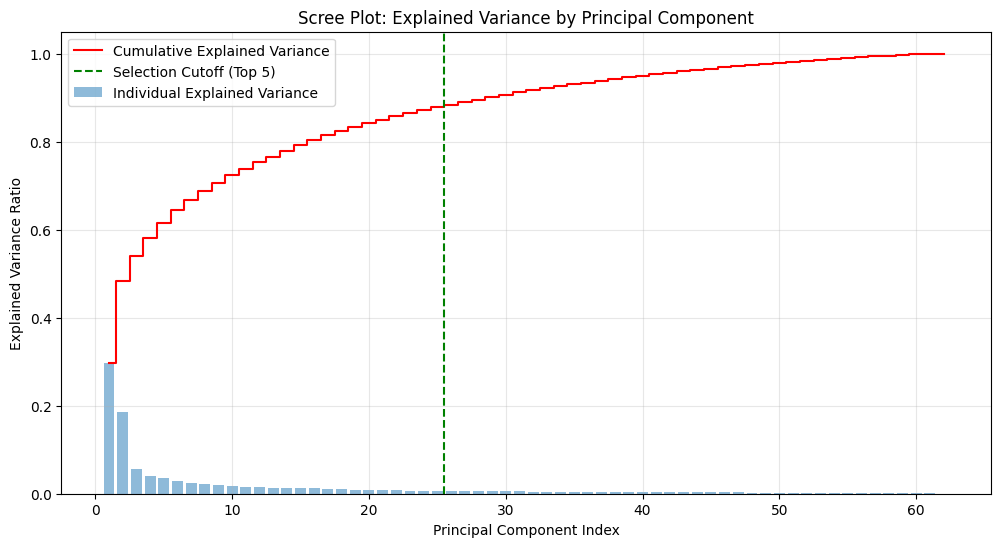

Variance explained by Top 10: 87.78%


In [151]:
pca = PCA()
pca.fit(X_scaled)

# 4. Create the Scree Plot
plt.figure(figsize=(12, 6))
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# Bar plot for individual variance
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.5, align='center', label='Individual Explained Variance')
# Step plot for cumulative variance
plt.step(range(1, len(exp_var) + 1), cum_var, where='mid', label='Cumulative Explained Variance', color='red')

# Vertical line at 5 to show your selection
plt.axvline(x=25.5, color='green', linestyle='--', label='Selection Cutoff (Top 5)')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot: Explained Variance by Principal Component')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

# Print the numbers for reference
print(f"Variance explained by Top 10: {sum(exp_var[:25]):.2%}")

In [152]:
#Apply PCA
pca_25 = PCA(n_components=25)
X_pca = pca_25.fit_transform(X_scaled)

# Eigenvalues for these 5 components
eigenvalues = pca_25.explained_variance_

#Create and Save the Reduced Dataset
pca_columns = [f'PC{i+1}' for i in range(25)]
df_pca = pd.DataFrame(data=X_pca, columns=pca_columns)
df_pca['Kingdom'] = y.values

In [153]:
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,Kingdom
0,5.999607,-0.110518,3.624183,-2.226701,0.959577,1.476934,-0.252336,-0.708389,-0.505336,-1.730777,...,-0.872885,-1.447775,0.054360,-0.089393,-0.424739,-0.837635,-0.514593,0.471557,-0.290105,vrl
1,5.585957,-0.273068,4.076570,-1.804301,-0.747029,1.178151,-1.544513,-1.309988,-0.412640,-1.676344,...,-0.076676,-0.045823,0.511744,-0.339438,-0.561600,-0.051212,0.962530,-0.322449,0.141626,vrl
2,-0.274695,-2.535389,1.838187,-2.299159,0.415666,-0.364983,-0.243076,0.255400,0.459756,0.439171,...,-0.981680,0.143479,-0.710796,-0.968506,-0.507073,0.023495,0.094500,0.387273,0.200335,vrl
3,-1.616704,-2.118830,1.556229,-1.328989,-0.272819,2.135633,-0.070702,-0.155886,0.617887,-1.513015,...,-0.295139,0.451240,-0.533989,0.252502,-1.034724,0.694537,-0.262238,0.909396,0.805527,vrl
4,-0.786983,-4.976234,0.499870,0.221165,0.152280,0.011056,0.056625,-0.583426,-0.031140,-0.958820,...,-0.499746,-0.530838,-0.699213,0.730259,0.873118,0.765742,0.135460,-0.745189,-0.348492,vrl


In [154]:
# Results Output
print(f"Top 10 Eigenvalues: {eigenvalues}")
print(f"Total Variance Explained by Top 25: {np.sum(pca_25.explained_variance_ratio_):.2%}")

Top 10 Eigenvalues: [18.4492534  11.55993112  3.43955487  2.52987285  2.15081686  1.78363589
  1.44298222  1.31619243  1.16636315  1.05523558  0.91664003  0.87759311
  0.82373044  0.79084275  0.76959745  0.73958292  0.67271048  0.61066956
  0.59363631  0.53307854  0.48376275  0.46220441  0.43510044  0.42065964
  0.40600265]
Total Variance Explained by Top 25: 87.78%


# KNN Model with highest 25 PCs

In [155]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import f1_score, classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE



# 1. Train-Test Split (Crucial step added here)
# We allocate 20% of the data to testing and keep 80% for training/validation
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2. Set up the Pipeline
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(metric='euclidean'))
])

# 3. Define Grid Search Parameters
param_grid = {
    'knn__n_neighbors': [1, 2, 3, 4, 5]
}

# 4. Initialize Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# 5. Fit the model on the TRAINING data only
print("Running Grid Search with 5-Fold CV on Training Data...")
grid_search.fit(X_train, y_train)

# 6. Display Cross-Validation Results
print("\n--- Cross-Validation Results (Training Data) ---")
for i, params in enumerate(grid_search.cv_results_['params']):
    score = grid_search.cv_results_['mean_test_score'][i]
    print(f"k = {params['knn__n_neighbors']}: Macro F1-Score = {score:.4f}")

print(f"\nBest 'k' value found during CV: {grid_search.best_params_['knn__n_neighbors']}")
print(f"Best CV Macro F1-Score: {grid_search.best_score_:.4f}")

# 7. Final Evaluation on Unseen Test Data
print("\n--- Final Evaluation on Unseen Test Data ---")
# grid_search automatically refits the best model on the entire X_train dataset
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Calculate the final Macro F1-Score
test_f1 = f1_score(y_test, y_pred, average='macro')
print(f"True Test Macro F1-Score: {test_f1:.4f}")


print(classification_report(y_test, y_pred))

Running Grid Search with 5-Fold CV on Training Data...

--- Cross-Validation Results (Training Data) ---
k = 1: Macro F1-Score = 0.8827
k = 2: Macro F1-Score = 0.8661
k = 3: Macro F1-Score = 0.8669
k = 4: Macro F1-Score = 0.8532
k = 5: Macro F1-Score = 0.8536

Best 'k' value found during CV: 1
Best CV Macro F1-Score: 0.8827

--- Final Evaluation on Unseen Test Data ---
True Test Macro F1-Score: 0.8641
              precision    recall  f1-score   support

         arc       0.59      0.80      0.68        25
         bct       0.93      0.93      0.93       584
         inv       0.86      0.85      0.86       269
         mam       0.91      0.94      0.93       193
         phg       0.67      0.68      0.67        44
         pln       0.94      0.93      0.94       505
         vrl       0.96      0.96      0.96       567
         vrt       0.95      0.94      0.94       415

    accuracy                           0.93      2602
   macro avg       0.85      0.88      0.86      2602

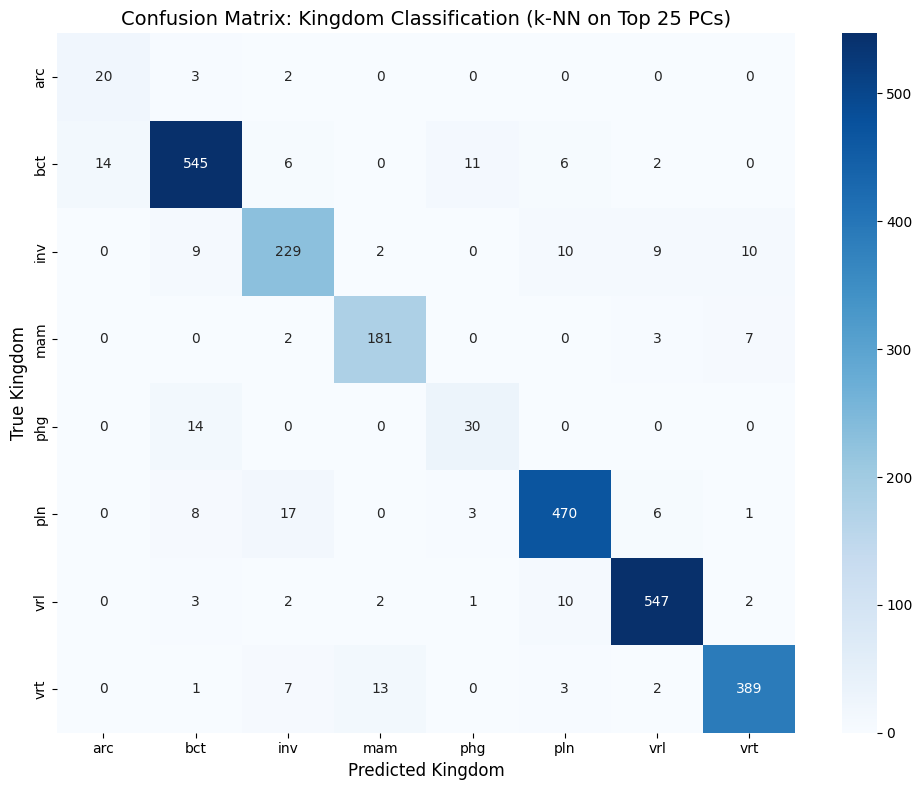

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

# 2. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.title('Confusion Matrix: Kingdom Classification (k-NN on Top 25 PCs)', fontsize=14)
plt.ylabel('True Kingdom', fontsize=12)
plt.xlabel('Predicted Kingdom', fontsize=12)
plt.tight_layout()

plt.show()

# KNN Model with all the 64 features

In [157]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import f1_score, classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE



# 1. Train-Test Split (Crucial step added here)
# We allocate 20% of the data to testing and keep 80% for training/validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2. Set up the Pipeline.
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(metric='euclidean'))
])

# 3. Define Grid Search Parameters
param_grid = {
    'knn__n_neighbors': [1, 2, 3, 4, 5]
}

# 4. Initialize Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# 5. Fit the model on the TRAINING data only
print("Running Grid Search with 5-Fold CV on Training Data...")
grid_search.fit(X_train, y_train)

# 6. Display Cross-Validation Results
print("\n--- Cross-Validation Results (Training Data) ---")
for i, params in enumerate(grid_search.cv_results_['params']):
    score = grid_search.cv_results_['mean_test_score'][i]
    print(f"k = {params['knn__n_neighbors']}: Macro F1-Score = {score:.4f}")

print(f"\nBest 'k' value found during CV: {grid_search.best_params_['knn__n_neighbors']}")
print(f"Best CV Macro F1-Score: {grid_search.best_score_:.4f}")

# 7. Final Evaluation on Unseen Test Data
print("\n--- Final Evaluation on Unseen Test Data ---")
# grid_search automatically refits the best model on the entire X_train dataset
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Calculate the final Macro F1-Score to report in your project
test_f1 = f1_score(y_test, y_pred, average='macro')
print(f"True Test Macro F1-Score: {test_f1:.4f}")


print(classification_report(y_test, y_pred))

Running Grid Search with 5-Fold CV on Training Data...

--- Cross-Validation Results (Training Data) ---
k = 1: Macro F1-Score = 0.9029
k = 2: Macro F1-Score = 0.8825
k = 3: Macro F1-Score = 0.8801
k = 4: Macro F1-Score = 0.8697
k = 5: Macro F1-Score = 0.8626

Best 'k' value found during CV: 1
Best CV Macro F1-Score: 0.9029

--- Final Evaluation on Unseen Test Data ---
True Test Macro F1-Score: 0.8849
              precision    recall  f1-score   support

         arc       0.61      0.88      0.72        25
         bct       0.96      0.93      0.95       584
         inv       0.89      0.90      0.89       269
         mam       0.95      0.98      0.97       193
         phg       0.67      0.68      0.67        44
         pln       0.94      0.95      0.94       505
         vrl       0.97      0.97      0.97       567
         vrt       0.98      0.96      0.97       415

    accuracy                           0.94      2602
   macro avg       0.87      0.91      0.88      2602

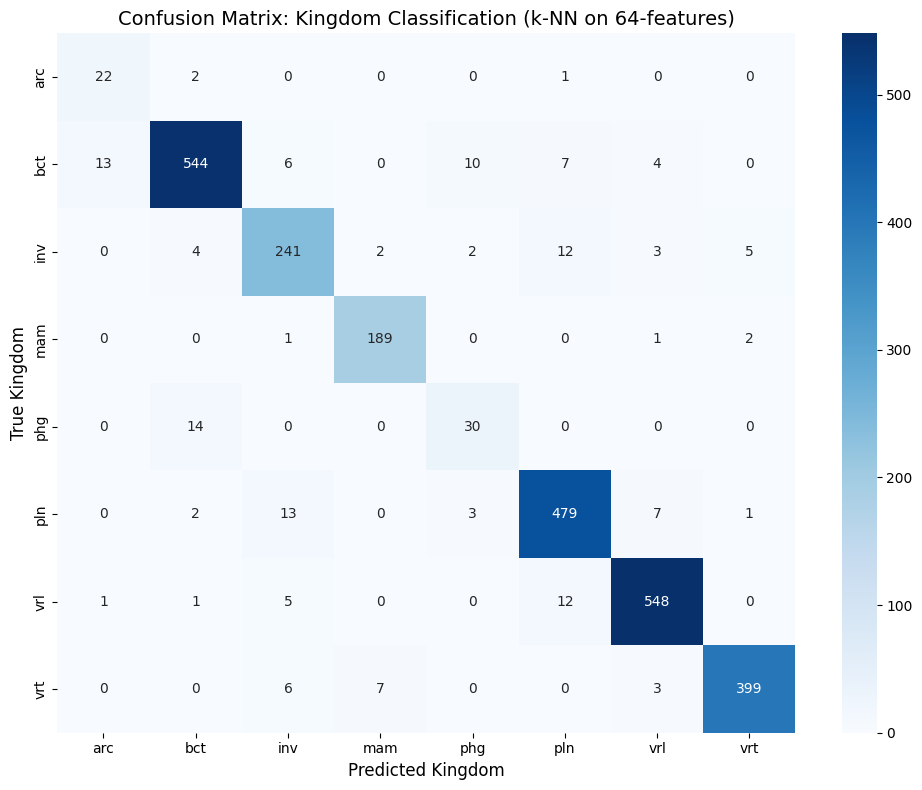

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

# 2. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # Show the numbers
    fmt='d',             # Show as integers
    cmap='Blues',        # Professional color scheme
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.title('Confusion Matrix: Kingdom Classification (k-NN on 64-features)', fontsize=14)
plt.ylabel('True Kingdom', fontsize=12)
plt.xlabel('Predicted Kingdom', fontsize=12)
plt.tight_layout()

plt.show()